In [1]:
# Problem framing module for block 1: "Frame the problem and look at the big picture"
# English block docstrings and @param annotations as requested.
# Debug prints are in Portuguese and verbose to simulate an "AI" explaining steps.

from typing import Optional, Dict, Any
import pandas as pd
import numpy as np

class ProblemFramer:
    """
    ProblemFramer collects and validates the problem statement and dataset metadata,
    and guides the user into explicit business-oriented framing needed before modelling.

    @param dataset_dataframe: optional pandas.DataFrame containing the dataset to analyze
    @param target_column_name: optional name of the target column if already known
    @param id_column_name: optional name of ID column if present (used to check uniqueness)
    """

    def __init__(self,
                 dataset_dataframe: Optional[pd.DataFrame] = None,
                 target_column_name: Optional[str] = None,
                 id_column_name: Optional[str] = None):
        self.dataset_dataframe = dataset_dataframe
        self.target_column_name = target_column_name
        self.id_column_name = id_column_name
        # small lambdas for quick checks
        self._is_categorical = lambda series: (series.dtype == object) or (series.nunique() <= 30)
        self._safe_div = lambda a, b: a / b if b != 0 else np.nan
        print("[AI DEBUG] Inicializando ProblemFramer")

    def ingestDataset(self, dataframe: pd.DataFrame, target_column_name: Optional[str] = None, id_column_name: Optional[str] = None) -> None:
        """
        Ingest dataset into the framer.

        @param dataframe: pandas.DataFrame with data
        @param target_column_name: optional string naming the target column
        @param id_column_name: optional string naming the ID column
        @return: None
        """
        print("[AI DEBUG] Ingesting dataset into ProblemFramer")
        self.dataset_dataframe = dataframe.copy()
        if target_column_name:
            self.target_column_name = target_column_name
            print(f"[AI DEBUG] Target column set to: {self.target_column_name}")
        if id_column_name:
            self.id_column_name = id_column_name
            print(f"[AI DEBUG] ID column set to: {self.id_column_name}")
        print(f"[AI DEBUG] Dataset shape: {self.dataset_dataframe.shape}")

    def summarizeDatasetMetadata(self) -> Dict[str, Any]:
        """
        Return a dictionary with core dataset metadata useful for framing.

        @return: dict with keys: numRows, numColumns, missingValuesByColumn, sampleOfRows, idColumnIsUnique
        """
        print("[AI DEBUG] Summarizando metadados do dataset")
        if self.dataset_dataframe is None:
            raise ValueError("No dataset loaded. Call ingestDataset() first.")
        num_rows = len(self.dataset_dataframe)
        num_columns = len(self.dataset_dataframe.columns)
        missing_values = self.dataset_dataframe.isnull().sum().to_dict()
        sample_of_rows = self.dataset_dataframe.head(5)
        id_column_is_unique = None
        if self.id_column_name and self.id_column_name in self.dataset_dataframe.columns:
            id_column_is_unique = self.dataset_dataframe[self.id_column_name].is_unique
            print(f"[AI DEBUG] ID column uniqueness check: {id_column_is_unique}")
        print(f"[AI DEBUG] Rows: {num_rows}, Columns: {num_columns}")
        return {
            "numRows": num_rows,
            "numColumns": num_columns,
            "missingValuesByColumn": missing_values,
            "sampleOfRows": sample_of_rows,
            "idColumnIsUnique": id_column_is_unique
        }

    def inferTaskType(self) -> Dict[str, Any]:
        """
        Infer whether the task is classification, regression, clustering, or multilabel
        based on the target column if available.

        @return: dict with keys: inferredTask, isTargetCategorical, classDistribution (if classification)
        """
        print("[AI DEBUG] Inferindo o tipo de tarefa a partir do target, se disponível")
        if self.dataset_dataframe is None or self.target_column_name is None:
            print("[AI DEBUG] Dataset ou target ausente; retornando 'unknown' para inferredTask")
            return {"inferredTask": "unknown", "isTargetCategorical": None, "classDistribution": None}

        if self.target_column_name not in self.dataset_dataframe.columns:
            raise KeyError(f"Target column '{self.target_column_name}' not found in dataset")

        target_series = self.dataset_dataframe[self.target_column_name]
        is_categorical_flag = bool(self._is_categorical(target_series))
        inferred_task = "classification" if is_categorical_flag else "regression"
        result = {"inferredTask": inferred_task, "isTargetCategorical": is_categorical_flag}
        print(f"[AI DEBUG] Inferred task: {inferred_task}, is categorical: {is_categorical_flag}")

        if is_categorical_flag:
            distribution = target_series.value_counts(dropna=False).to_dict()
            class_counts = distribution
            total_count = len(target_series)
            class_proportions = {k: (v, round(self._safe_div(v, total_count), 4)) for k, v in class_counts.items()}
            result["classDistribution"] = class_proportions
            print(f"[AI DEBUG] Class distribution computed: {class_proportions}")
        return result

    def proposePerformanceMetrics(self) -> Dict[str, str]:
        """
        Propose appropriate performance metrics given the inferred task.

        @return: dict with keys: recommendedPrimaryMetric, recommendedSecondaryMetric, rationale
        """
        print("[AI DEBUG] Propondo métricas de performance apropriadas")
        inferred = self.inferTaskType().get("inferredTask", "unknown")
        if inferred == "classification":
            primary_metric = "roc_auc"
            secondary_metric = "f1_score"
            rationale_text = "Use ROC AUC for overall separability and F1 for class balance and operational trade-offs."
        elif inferred == "regression":
            primary_metric = "root_mean_squared_error"
            secondary_metric = "mean_absolute_error"
            rationale_text = "Use RMSE for penalizing large errors and MAE for interpretable average error."
        elif inferred == "unknown":
            primary_metric = "tbd"
            secondary_metric = "tbd"
            rationale_text = "Unable to infer task: provide target column or specify task type."
        else:
            primary_metric = "tbd"
            secondary_metric = "tbd"
            rationale_text = "For clustering consider silhouette_score and adjusted_mutual_info_score if ground truth exists."
        print(f"[AI DEBUG] Recomendações: primary={primary_metric}, secondary={secondary_metric}")
        return {"recommendedPrimaryMetric": primary_metric,
                "recommendedSecondaryMetric": secondary_metric,
                "rationale": rationale_text}

    def suggestMinimumAcceptablePerformance(self, baselinePerformanceValue: Optional[float] = None) -> Dict[str, Any]:
        """
        Suggest a minimum performance threshold based on dataset and a supplied baseline.

        @param baselinePerformanceValue: optional numeric baseline (e.g., existing model or heuristic)
        @return: dict with suggestedMinimum and explanation
        """
        print("[AI DEBUG] Sugerindo performance mínima aceitável com base no baseline informado")
        inferred = self.inferTaskType().get("inferredTask", "unknown")
        if baselinePerformanceValue is None:
            suggestion = None
            explanation = "No baseline provided; please provide existing performance or business target to suggest minimum."
            print("[AI DEBUG] Nenhum baseline fornecido")
        else:
            if inferred == "classification":
                suggested_minimum = round(min(0.99, baselinePerformanceValue * 1.02), 4)  # small improvement target
                suggestion = suggested_minimum
                explanation = "Suggest improving current baseline by ~2% relative when feasible."
            elif inferred == "regression":
                suggested_minimum = round(max(0.0, baselinePerformanceValue * 0.98), 4)  # smaller RMSE is better
                suggestion = suggested_minimum
                explanation = "Suggest decreasing RMSE by ~2% relative when feasible."
            else:
                suggestion = None
                explanation = "Task unknown; cannot propose numeric minimum automatically."
            print(f"[AI DEBUG] Suggested minimum computed: {suggestion}")
        return {"suggestedMinimum": suggestion, "explanation": explanation}

    def listChecklistItemsNotApplicable(self, customNotes: Optional[str] = None) -> Dict[str, Any]:
        """
        Return justification entries for checklist items that might be intentionally skipped.

        @param customNotes: optional text explaining why items are skipped
        @return: dict with a single key 'justifications' containing the note
        """
        print("[AI DEBUG] Registrando justificativas para itens do checklist não aplicados")
        note_text = customNotes if customNotes else "No exceptions recorded."
        return {"justifications": note_text}

# Example usage
if __name__ == "__main__":
    print("Instanciando ProblemFramer e rodando checks iniciais")
    # If you have a pandas DataFrame loaded from the Breast Cancer dataset, pass it here:
    # df = pd.read_csv("path_to_wdbc.csv")
    # For demonstration create a minimal fake DataFrame similar to WDBC
    demo_df = pd.DataFrame({
        "id": [1, 2, 3],
        "diagnosis": ["M", "B", "B"],
        "mean_radius": [17.99, 20.57, 19.69],
        "mean_texture": [10.38, 17.77, 21.25]
    })
    framer = ProblemFramer(dataset_dataframe=demo_df, target_column_name="diagnosis", id_column_name="id")
    metadata = framer.summarizeDatasetMetadata()
    print("[AI DEBUG] Metadata summary keys:", list(metadata.keys()))
    inference = framer.inferTaskType()
    print("[AI DEBUG] Inference result:", inference)
    metrics = framer.proposePerformanceMetrics()
    print("[AI DEBUG] Metrics suggested:", metrics)
    minPerf = framer.suggestMinimumAcceptablePerformance(baselinePerformanceValue=0.90)
    print("[AI DEBUG] Minimum performance suggestion:", minPerf)


Instanciando ProblemFramer e rodando checks iniciais
[AI DEBUG] Inicializando ProblemFramer
[AI DEBUG] Summarizando metadados do dataset
[AI DEBUG] ID column uniqueness check: True
[AI DEBUG] Rows: 3, Columns: 4
[AI DEBUG] Metadata summary keys: ['numRows', 'numColumns', 'missingValuesByColumn', 'sampleOfRows', 'idColumnIsUnique']
[AI DEBUG] Inferindo o tipo de tarefa a partir do target, se disponível
[AI DEBUG] Inferred task: classification, is categorical: True
[AI DEBUG] Class distribution computed: {'B': (2, 0.6667), 'M': (1, 0.3333)}
[AI DEBUG] Inference result: {'inferredTask': 'classification', 'isTargetCategorical': True, 'classDistribution': {'B': (2, 0.6667), 'M': (1, 0.3333)}}
[AI DEBUG] Propondo métricas de performance apropriadas
[AI DEBUG] Inferindo o tipo de tarefa a partir do target, se disponível
[AI DEBUG] Inferred task: classification, is categorical: True
[AI DEBUG] Class distribution computed: {'B': (2, 0.6667), 'M': (1, 0.3333)}
[AI DEBUG] Recomendações: primary=r

In [5]:
# Data acquisition "big block" ready for Colab / script
# Object-oriented, camelCase, atomic functions, lambdas when useful.
# Block comments and @param in English. Debug prints in Portuguese to simulate an AI explaining steps.

"""
DataManager: acquire and prepare the Breast Cancer dataset.

Responsibility: list needs, find sources, check storage, download via kagglehub (preferred),
normalize to CSV, anonymize protected columns (placeholder), inspect size & type,
and create a hold-out test set stored in memory.

@param workspaceDirectoryPath: directory where downloads and processed files will be kept
@param preferredKaggleDatasetSlug: kaggle dataset slug to attempt download via kagglehub
@param desiredTestRatio: fraction of data to hold out for final test set
@param randomState: integer seed for reproducible splits
@return: instance attributes populated: dataFrame, X_train, X_test, y_train, y_test, targetVariable
"""

from pathlib import Path
from typing import Optional, Tuple, List
import os
import subprocess
import sys

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

# reproducibility constant
RANDOM_STATE = 42

class DataManager:
    """
    DataManager orchestrates data acquisition and initial preparation.

    @param workspaceDirectoryPath: str path for workspace
    @param preferredKaggleDatasetSlug: str kaggle dataset slug (kagglehub)
    @param desiredTestRatio: float fraction to reserve for test set
    @param randomState: int seed for reproducibility
    """

    def __init__(self,
                 workspaceDirectoryPath: str = "wdbc_workspace",
                 preferredKaggleDatasetSlug: str = "yasserh/breast-cancer-dataset",
                 desiredTestRatio: float = 0.2,
                 randomState: int = RANDOM_STATE):
        self.workspaceDirectoryPath = Path(workspaceDirectoryPath)
        self.rawDataDirectoryPath = self.workspaceDirectoryPath / "raw"
        self.processedDataDirectoryPath = self.workspaceDirectoryPath / "processed"
        self.preferredKaggleDatasetSlug = preferredKaggleDatasetSlug
        self.desiredTestRatio = desiredTestRatio
        self.randomState = randomState

        # outputs to be populated
        self.dataFrame: Optional[pd.DataFrame] = None
        self.targetVariable: Optional[str] = None
        self.X_train: Optional[pd.DataFrame] = None
        self.X_test: Optional[pd.DataFrame] = None
        self.y_train: Optional[pd.Series] = None
        self.y_test: Optional[pd.Series] = None

        # small lambdas
        self._is_csv = lambda filename: str(filename).lower().endswith(".csv")
        self._make_path = lambda p: Path(p)
        self._ensure_dir = lambda p: Path(p).mkdir(parents=True, exist_ok=True)
        print("[AI DEBUG] Inicializando DataManager")

    def _ensureWorkspace(self) -> None:
        """
        Create workspace directories if missing.

        @return: None
        """
        print("[AI DEBUG] Criando/verificando workspace e diretórios")
        for directory in (self.workspaceDirectoryPath, self.rawDataDirectoryPath, self.processedDataDirectoryPath):
            self._ensure_dir(directory)
            print(f"[AI DEBUG] Diretório pronto: {directory}")

    def _ensureKagglehubInstalled(self) -> None:
        """
        Ensure kagglehub is available; if not, install it via pip.

        @return: None
        """
        try:
            import kagglehub  # type: ignore
            print("[AI DEBUG] kagglehub disponível no ambiente")
        except Exception:
            print("[AI DEBUG] kagglehub não encontrado; instalando via pip (quiet)...")
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
            print("[AI DEBUG] kagglehub instalado; importando...")
            import kagglehub  # type: ignore

    def _downloadWithKagglehub(self, datasetSlug: str) -> Path:
        """
        Download the dataset using kagglehub into the raw directory.

        @param datasetSlug: kaggle dataset slug string
        @return: Path to the folder or file returned by kagglehub
        """
        self._ensureWorkspace()
        self._ensureKagglehubInstalled()
        import kagglehub  # type: ignore

        print(f"[AI DEBUG] Iniciando download com kagglehub: {datasetSlug}")
        # kagglehub.dataset_download often returns a path string
        result = kagglehub.dataset_download(datasetSlug, path=str(self.rawDataDirectoryPath))
        result_path = Path(result) if isinstance(result, (str, Path)) else self.rawDataDirectoryPath
        print(f"[AI DEBUG] kagglehub finalizou. Resultado: {result_path}")
        return result_path

    def _listCsvFilesInPath(self, candidatePath: Path) -> List[Path]:
        """
        Return list of CSV files found under the candidate path (file or directory).

        @param candidatePath: Path to examine
        @return: list of Path objects pointing to csv files
        """
        print(f"[AI DEBUG] Procurando arquivos CSV em: {candidatePath}")
        if candidatePath.is_dir():
            csvs = [p for p in candidatePath.iterdir() if p.is_file() and self._is_csv(p.name)]
            print(f"[AI DEBUG] CSVs encontrados no diretório: {[str(p) for p in csvs]}")
            return csvs
        else:
            if self._is_csv(candidatePath.name):
                print(f"[AI DEBUG] O arquivo retornado é CSV: {candidatePath}")
                return [candidatePath]
            # if not csv, maybe it's an archive: look for extracted folder with same stem
            extracted_folder = self.rawDataDirectoryPath / candidatePath.stem
            if extracted_folder.exists():
                return self._listCsvFilesInPath(extracted_folder)
            print("[AI DEBUG] Nenhum CSV detectado diretamente no caminho fornecido")
            return []

    def _extractArchiveIfNeeded(self, archivePath: Path) -> Path:
        """
        If the given path is an archive (zip, tgz), extract it to a sibling folder and return that folder.

        @param archivePath: Path to the archive
        @return: Path to extraction folder or original path if no extraction needed
        """
        import tarfile
        import zipfile

        if not archivePath.exists():
            raise FileNotFoundError(f"Archive not found: {archivePath}")

        lower_suffix = archivePath.suffix.lower()
        if lower_suffix in {".tgz", ".tar", ".gz"} and tarfile.is_tarfile(archivePath):
            extract_to = self.rawDataDirectoryPath / archivePath.stem
            self._ensure_dir(extract_to)
            print(f"[AI DEBUG] Extraindo tarball {archivePath} para {extract_to}")
            with tarfile.open(archivePath) as tf:
                tf.extractall(path=extract_to)
            return extract_to
        if lower_suffix == ".zip":
            extract_to = self.rawDataDirectoryPath / archivePath.stem
            self._ensure_dir(extract_to)
            print(f"[AI DEBUG] Extraindo zip {archivePath} para {extract_to}")
            with zipfile.ZipFile(archivePath, "r") as zf:
                zf.extractall(path=extract_to)
            return extract_to
        return archivePath

    def _loadCsvToDataFrame(self, csvPath: Path) -> pd.DataFrame:
        """
        Load CSV into pandas DataFrame with cautious defaults.

        @param csvPath: Path to the CSV file
        @return: pandas.DataFrame
        """
        print(f"[AI DEBUG] Carregando CSV para DataFrame: {csvPath}")
        df = pd.read_csv(csvPath)
        print(f"[AI DEBUG] CSV carregado. Shape: {df.shape}")
        return df

    def _fallbackLoadFromSklearn(self) -> pd.DataFrame:
        """
        Fallback loader using sklearn's built-in breast cancer dataset.

        @return: pandas.DataFrame with data and a 'target' column
        """
        print("[AI DEBUG] Carregando dataset de fallback do sklearn.datasets.load_breast_cancer()")
        payload = load_breast_cancer()
        df = pd.DataFrame(payload.data, columns=[c.replace(" ", "_") for c in payload.feature_names])
        df["target"] = payload.target
        print(f"[AI DEBUG] Fallback dataset loaded. Shape: {df.shape}")
        return df

    def _anonymizeColumnsIfNeeded(self, dataframe: pd.DataFrame, columnsToMask: Optional[List[str]] = None) -> pd.DataFrame:
        """
        Mask provided columns by replacing values with 'REDACTED'. Placeholder: adapt to policy.

        @param dataframe: pandas.DataFrame to process
        @param columnsToMask: list of column names to redact
        @return: new DataFrame with masked columns (if any)
        """
        columnsToMask = columnsToMask or []
        if not columnsToMask:
            print("[AI DEBUG] Nenhuma coluna a mascarar especificada; pulando anonimização")
            return dataframe
        df = dataframe.copy()
        for col in columnsToMask:
            if col in df.columns:
                df[col] = df[col].apply(lambda _: "REDACTED")
                print(f"[AI DEBUG] Coluna mascarada: {col}")
            else:
                print(f"[AI DEBUG] Coluna para mascarar não encontrada: {col}")
        return df

    def _identifyAndSetTarget(self, dataframe: pd.DataFrame, potentialTargets: Optional[List[str]] = None) -> str:
        """
        Identify target column from common names or fallback to last column.

        @param dataframe: pandas.DataFrame to inspect
        @param potentialTargets: optional list of candidate names
        @return: chosen target column name
        """
        potentialTargets = potentialTargets or ['target', 'diagnosis', 'class', 'outcome']
        for candidate in potentialTargets:
            if candidate in dataframe.columns:
                print(f"[AI DEBUG] Target detected: {candidate}")
                return candidate
        fallback = dataframe.columns[-1]
        print(f"[AI DEBUG] Nenhum target óbvio encontrado; usando última coluna: {fallback}")
        return fallback

    def _encodeTargetIfNeeded(self, y_series: pd.Series) -> pd.Series:
        """
        Encode string labels to numeric (e.g., 'M'/'B' -> 1/0). Return transformed series.

        @param y_series: pandas.Series with target values
        @return: encoded pandas.Series (int/float)
        """
        if y_series.dtype == object or y_series.dtype.name == "category":
            unique_vals = y_series.unique()
            mapping = {v: i for i, v in enumerate(sorted(unique_vals))}
            print(f"[AI DEBUG] Encoding target using mapping: {mapping}")
            return y_series.map(lambda v: mapping[v]).astype(int)
        return y_series

    def getData(self) -> None:
        """
        Acquire and prepare the dataset end-to-end according to the checklist.

        Steps printed in Portuguese to simulate an AI narrating actions.
        Populates self.dataFrame, self.targetVariable, and train/test splits.
        """
        print("1. List the data you need and how much you need.")
        print("   Need: Breast cancer diagnostic data with 30 numeric features computed from FNA images. Need at least several hundred samples for robust cross-validation.")

        print("\n2. Find and document where you can get that data.")
        print(f"   Preferred source: Kaggle dataset slug: {self.preferredKaggleDatasetSlug}")

        print("\n3. Check how much space it will take.")
        print("   Expected size: very small (tens to hundreds of KB). Storage overhead negligible.")

        print("\n4. Check legal obligations, and get authorization if necessary.")
        print("   Dataset typically under CC BY 4.0 (UCI/Kaggle copies). Review license if redistributing or commercializing.")

        print("\n5. Get access authorizations.")
        print("   Access method: kagglehub (no kaggle.json needed). If using official Kaggle API, ensure kaggle.json present or env vars set.")

        print("\n6. Create a workspace (with enough storage space).")
        self._ensureWorkspace()

        print("\n7. Get the data.")
        downloaded_candidate_path = None
        try:
            downloaded_candidate_path = self._downloadWithKagglehub(self.preferredKaggleDatasetSlug)
            # if an archive file was returned, attempt extraction
            downloaded_candidate_path = self._extractArchiveIfNeeded(Path(downloaded_candidate_path))
            csv_candidates = self._listCsvFilesInPath(downloaded_candidate_path)
            if csv_candidates:
                chosen_csv = csv_candidates[0]
                self.dataFrame = self._loadCsvToDataFrame(chosen_csv)
                print(f"   Dataset downloaded and loaded from kagglehub. Shape: {self.dataFrame.shape}")
            else:
                raise FileNotFoundError("No CSV found in kagglehub download location")
        except Exception as e:
            print(f"   Erro no download a partir do kagglehub ou carregamento do CSV: {e}")
            print("   Carregando dataset de fallback do sklearn (load_breast_cancer)...")
            self.dataFrame = self._fallbackLoadFromSklearn()

        print("\n8. Convert the data to a format you can easily manipulate (without changing the data itself).")
        print("   Using pandas DataFrame as canonical in-memory representation.")

        print("\n9. Ensure sensitive information is deleted or protected (e.g., anonymized).")
        # placeholder: WDBC has no PII, but demonstrate API
        self.dataFrame = self._anonymizeColumnsIfNeeded(self.dataFrame, columnsToMask=[])  # adapt as needed

        print("\n10. Check the size and type of data (time series, sample, geographical, etc.).")
        rows_count, cols_count = self.dataFrame.shape
        print(f"   Data type: Tabular. Samples: {rows_count}, Features (including target if present): {cols_count}")

        print("\n11. Sample a test set, put it aside, and never look at it (no data snooping!).")
        # identify target
        self.targetVariable = self._identifyAndSetTarget(self.dataFrame)
        # separate X/y
        X = self.dataFrame.drop(columns=[self.targetVariable])
        y = self.dataFrame[self.targetVariable]

        # encode target if categorical strings
        y_encoded = self._encodeTargetIfNeeded(y)

        # stratify if classification (few unique values)
        is_classification = True if y_encoded.nunique() <= 20 and y_encoded.dtype in [np.int64, np.int32, np.int16, np.int8] else False
        stratify_arg = y_encoded if is_classification else None

        # perform split
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y_encoded, test_size=self.desiredTestRatio, random_state=self.randomState, stratify=stratify_arg)

        print(f"   Test set created with {len(self.y_test)} samples ({int(self.desiredTestRatio*100)}% of total).")
        print("[AI DEBUG] getData finished. Attributes populated: dataFrame, targetVariable, X_train, X_test, y_train, y_test")


# Example usage (run in Colab)
if __name__ == "__main__":
    manager = DataManager(workspaceDirectoryPath="wdbc_workspace", preferredKaggleDatasetSlug="yasserh/breast-cancer-dataset")
    manager.getData()
    print("Preview of loaded data (top 3 rows):")
    print(manager.dataFrame.head(3))
    print("Target variable identified as:", manager.targetVariable)


[AI DEBUG] Inicializando DataManager
1. List the data you need and how much you need.
   Need: Breast cancer diagnostic data with 30 numeric features computed from FNA images. Need at least several hundred samples for robust cross-validation.

2. Find and document where you can get that data.
   Preferred source: Kaggle dataset slug: yasserh/breast-cancer-dataset

3. Check how much space it will take.
   Expected size: very small (tens to hundreds of KB). Storage overhead negligible.

4. Check legal obligations, and get authorization if necessary.
   Dataset typically under CC BY 4.0 (UCI/Kaggle copies). Review license if redistributing or commercializing.

5. Get access authorizations.
   Access method: kagglehub (no kaggle.json needed). If using official Kaggle API, ensure kaggle.json present or env vars set.

6. Create a workspace (with enough storage space).
[AI DEBUG] Criando/verificando workspace e diretórios
[AI DEBUG] Diretório pronto: wdbc_workspace
[AI DEBUG] Diretório pronto

Demo: running EDA on sklearn breast cancer dataset as example
[AI DEBUG] ExploratoryAnalyzer inicializado
1. Criando cópia dos dados para exploração
   Dataset em tamanho manejável; usando cópia completa para exploração
   Cópia criada com shape: (569, 31)
3. Estudando cada atributo: nome, tipo, % missing, ruído estimado, utilidade preliminar


,name,dtype,missing_count,missing_pct,unique_count
0,mean_radius,float64,0,0.0,456
1,mean_texture,float64,0,0.0,479
2,mean_perimeter,float64,0,0.0,522
3,mean_area,float64,0,0.0,539
4,mean_smoothness,float64,0,0.0,474
5,mean_compactness,float64,0,0.0,537
6,mean_concavity,float64,0,0.0,537
7,mean_concave_points,float64,0,0.0,542
8,mean_symmetry,float64,0,0.0,432
9,mean_fractal_dimension,float64,0,0.0,499


   Estatísticas descritivas para atributos numéricos e categóricos
   No categorical columns to describe.


,count,mean,std,min,25%,50%,75%,max
mean_radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean_texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean_perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean_area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean_smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean_compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean_concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean_concave_points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean_symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean_fractal_dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


4. Identificando o(s) atributo(s) alvo para tarefas supervisionadas
   Target informado: target
   Target categórico detectado com distribuição: {1: 357, 0: 212}
   Visualizando distribuição do target


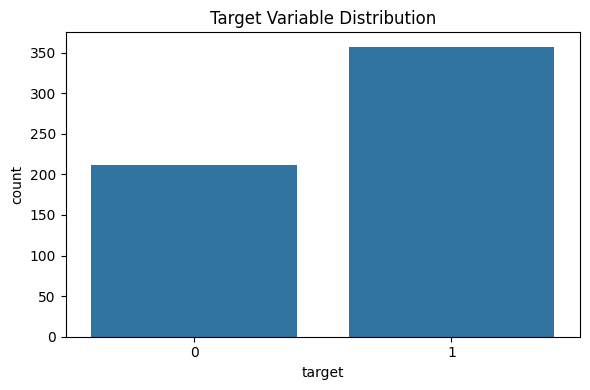

5. Visualizando atributos numéricos (histogramas + KDE)


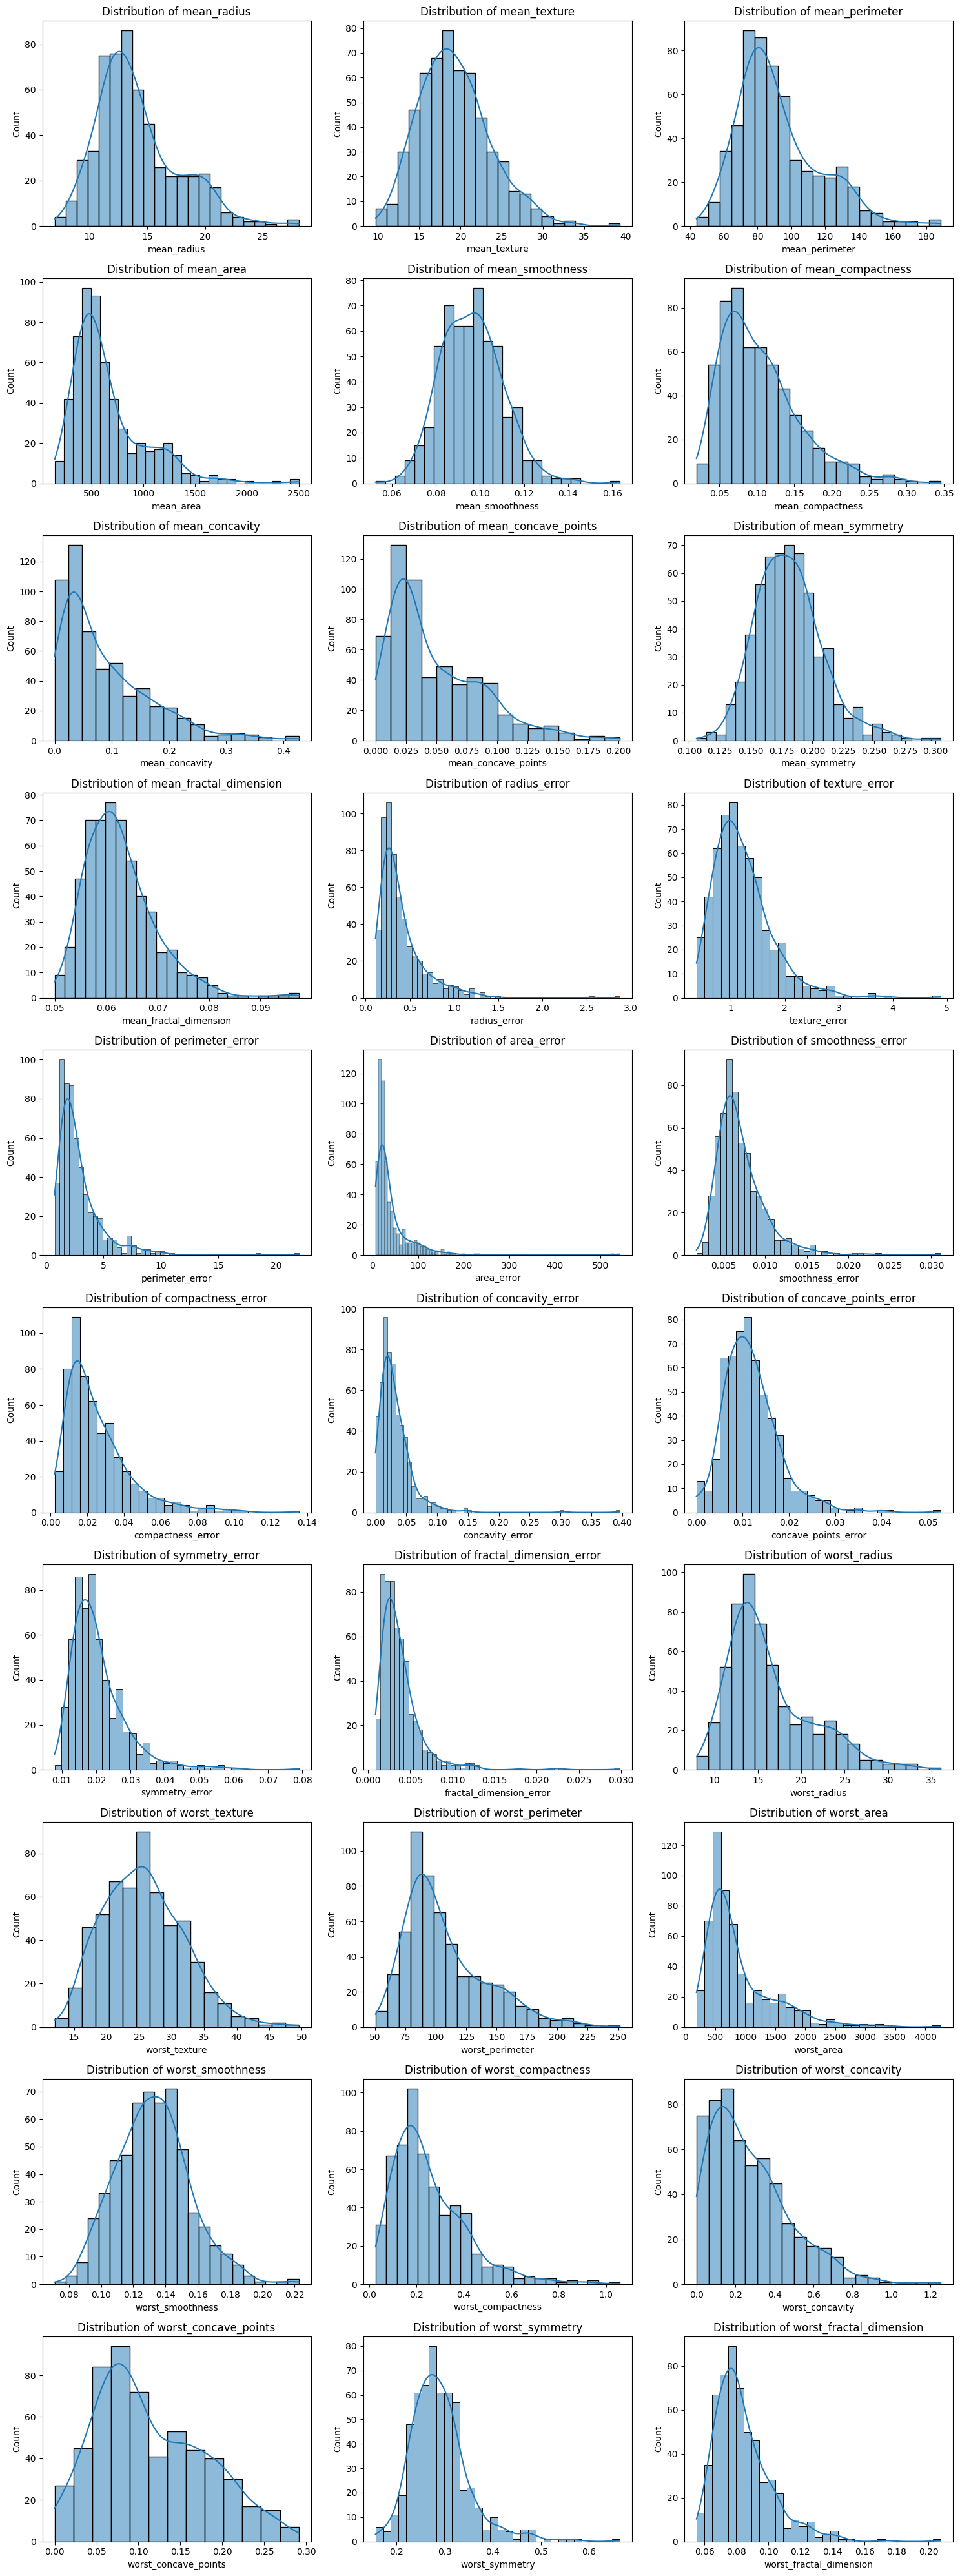

6. Estudando correlações entre atributos


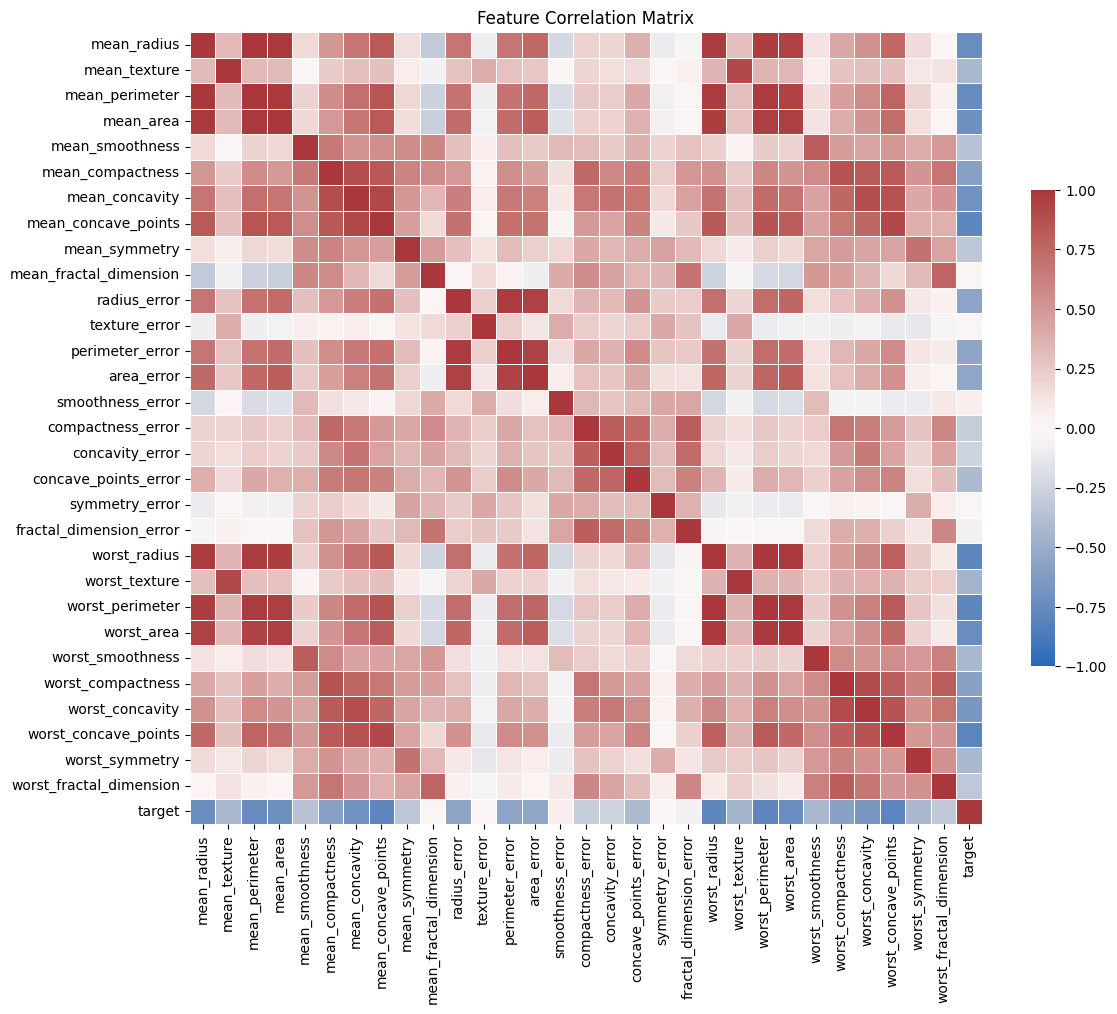

   Top features correlated with target (absolute correlation):


,abs_correlation
worst_concave_points,0.793566
worst_perimeter,0.782914
mean_concave_points,0.776614
worst_radius,0.776454
mean_perimeter,0.742636
worst_area,0.733825
mean_radius,0.730029
mean_area,0.708984
mean_concavity,0.696360
worst_concavity,0.659610


7. Estudando como resolver manualmente com expertise de domínio
   Manual solution sketch recorded
8. Identificando transformações promissoras
   Transformations suggested
9. Identificando dados extras úteis
   Suggested additional data: ['patient_demographics', 'family_history', 'genetic_markers', 'multi-modal imaging metadata']
10. Documentando o que foi aprendido durante a EDA


,value
targetColumn,target
targetIsCategorical,True
targetDistributionSample,"{1: 357, 0: 212}"
topCorrelatedWithTarget,"{'worst_concave_points': 0.79356601714127, 'wo..."
manualSolutionSketch,"Expert inspection of nucleus radius, texture, ..."
transformations,{'standardization': 'StandardScaler for numeri...
additionalDataSuggestions,"[patient_demographics, family_history, genetic..."
notes,EDA completed; consult findings keys for details


[AI DEBUG] EDA pipeline complete
Findings keys: ['targetColumn', 'targetIsCategorical', 'targetDistributionSample', 'topCorrelatedWithTarget', 'manualSolutionSketch', 'transformations', 'additionalDataSuggestions', 'notes']


In [7]:
# Exploratory Data Analysis module for Colab
# Block docstring in English with @param annotations as requested.
"""
ExploratoryAnalyzer: performs thorough EDA on a pandas DataFrame and produces
diagnostics, visualizations and a concise findings dictionary.

@param dataset_dataframe: pandas.DataFrame containing the dataset to explore
@param target_column_name: optional name of the target column (if None will be inferred)
@param sample_max_rows: max rows to keep for interactive visualizations to keep cells responsive
@param random_state: int seed for reproducibility of sampling
@return: populates analyzer attributes and returns a findings dict on request
"""

from typing import Optional, Dict, Any, List, Tuple
from dataclasses import dataclass, field
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

@dataclass
class ExploratoryAnalyzer:
    dataset_dataframe: pd.DataFrame
    target_column_name: Optional[str] = None
    sample_max_rows: int = 1000
    random_state: int = 42
    findings_summary: Dict[str, Any] = field(default_factory=dict)

    def __post_init__(self):
        # small lambdas and helpers
        self._is_categorical = lambda series: (series.dtype == object) or (series.nunique() <= 30)
        self._safe_div = lambda a, b: a / b if b != 0 else np.nan
        self._sample_df = lambda df: df.sample(n=min(len(df), self.sample_max_rows), random_state=self.random_state)
        print("[AI DEBUG] ExploratoryAnalyzer inicializado")

    def createExplorationCopy(self) -> pd.DataFrame:
        """
        Create a copy of the dataframe for exploration and optionally downsample.

        @return: pandas.DataFrame copy for exploration
        """
        print("1. Criando cópia dos dados para exploração")
        df_copy = self.dataset_dataframe.copy()
        if len(df_copy) > self.sample_max_rows:
            print(f"   Dataset grande ({len(df_copy)} linhas), amostrando até {self.sample_max_rows} linhas para EDA interativa")
            df_copy = self._sample_df(df_copy)
        else:
            print("   Dataset em tamanho manejável; usando cópia completa para exploração")
        print(f"   Cópia criada com shape: {df_copy.shape}")
        return df_copy

    def summarizeSchemaAndMissing(self, df_explore: pd.DataFrame) -> pd.DataFrame:
        """
        Produce schema summary with types and missing value statistics.

        @param df_explore: pandas.DataFrame used for exploration
        @return: pandas.DataFrame with columns: name, dtype, missing_count, missing_pct, unique_count
        """
        print("3. Estudando cada atributo: nome, tipo, % missing, ruído estimado, utilidade preliminar")
        col_names = []
        col_types = []
        missing_counts = []
        missing_pcts = []
        unique_counts = []
        for col in df_explore.columns:
            col_names.append(col)
            col_types.append(str(df_explore[col].dtype))
            missing_count = int(df_explore[col].isnull().sum())
            missing_counts.append(missing_count)
            missing_pcts.append(round(self._safe_div(missing_count, len(df_explore)) * 100, 3))
            unique_counts.append(int(df_explore[col].nunique(dropna=True)))
        schema_df = pd.DataFrame({
            "name": col_names,
            "dtype": col_types,
            "missing_count": missing_counts,
            "missing_pct": missing_pcts,
            "unique_count": unique_counts
        }).sort_values(by="missing_pct", ascending=False).reset_index(drop=True)
        display(schema_df)
        return schema_df

    def describeNumericAndCategorical(self, df_explore: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Show descriptive statistics separately for numeric and categorical attributes.

        @param df_explore: pandas.DataFrame used for exploration
        @return: tuple(numeric_description_df, categorical_description_df)
        """
        print("   Estatísticas descritivas para atributos numéricos e categóricos")
        numeric_df = df_explore.select_dtypes(include=[np.number])
        categorical_df = df_explore.select_dtypes(exclude=[np.number])
        num_desc = numeric_df.describe().T
        if not categorical_df.empty: # Add this check
            cat_desc = categorical_df.describe().T
            display(cat_desc)
        else:
            cat_desc = pd.DataFrame() # Return empty DataFrame if no categorical columns
            print("   No categorical columns to describe.") # Add a message
        display(num_desc)

        return num_desc, cat_desc

    def identifyTargetAndDistribution(self, df_explore: pd.DataFrame) -> Dict[str, Any]:
        """
        Identify target column and return its basic distribution stats.

        @param df_explore: pandas.DataFrame used for exploration
        @return: dict with targetColumn, isCategorical, valueCounts (if categorical) or summary stats
        """
        print("4. Identificando o(s) atributo(s) alvo para tarefas supervisionadas")
        if self.target_column_name and self.target_column_name in df_explore.columns:
            chosen_target = self.target_column_name
            print(f"   Target informado: {chosen_target}")
        else:
            candidates = ['target', 'diagnosis', 'class', 'outcome']
            chosen_target = next((c for c in candidates if c in df_explore.columns), df_explore.columns[-1])
            print(f"   Target inferido: {chosen_target}")
        target_series = df_explore[chosen_target]
        is_categorical_flag = self._is_categorical(target_series)
        distribution_info = None
        if is_categorical_flag:
            value_counts = target_series.value_counts(dropna=False)
            distribution_info = value_counts.to_dict()
            print(f"   Target categórico detectado com distribuição: {distribution_info}")
        else:
            distribution_info = target_series.describe().to_dict()
            print(f"   Target numérico detectado com estatísticas: {distribution_info}")
        self.findings_summary["targetColumn"] = chosen_target
        self.findings_summary["targetIsCategorical"] = is_categorical_flag
        self.findings_summary["targetDistributionSample"] = distribution_info
        # visualization
        print("   Visualizando distribuição do target")
        plt.figure(figsize=(6,4))
        if is_categorical_flag:
            sns.countplot(x=chosen_target, data=df_explore)
            plt.title("Target Variable Distribution")
        else:
            sns.histplot(target_series, kde=True)
            plt.title("Target Variable Distribution (numeric)")
        plt.tight_layout()
        plt.show()
        return {"targetColumn": chosen_target, "isCategorical": is_categorical_flag, "distribution": distribution_info}

    def plotNumericFeatureDistributions(self, df_explore: pd.DataFrame, excludeColumns: Optional[List[str]] = None) -> None:
        """
        Plot histograms with KDE for numeric features, skipping excluded columns.

        @param df_explore: pandas.DataFrame used for exploration
        @param excludeColumns: optional list of columns to exclude from plotting
        """
        print("5. Visualizando atributos numéricos (histogramas + KDE)")
        exclude = set(excludeColumns or [])
        numeric_cols = [c for c in df_explore.select_dtypes(include=[np.number]).columns if c not in exclude]
        if not numeric_cols:
            print("   Sem atributos numéricos para plotar")
            return
        cols_per_row = 3
        rows = (len(numeric_cols) + cols_per_row - 1) // cols_per_row
        fig, axes = plt.subplots(rows, cols_per_row, figsize=(5*cols_per_row, 4*rows))
        axes = axes.flatten()
        for i, feature in enumerate(numeric_cols):
            sns.histplot(df_explore[feature].dropna(), kde=True, ax=axes[i])
            axes[i].set_title(f"Distribution of {feature}")
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()

    def computeAndPlotCorrelations(self, df_explore: pd.DataFrame, annotateTopK: int = 10) -> pd.DataFrame:
        """
        Compute correlation matrix for numeric attributes, plot heatmap and show top correlations with target.

        @param df_explore: pandas.DataFrame used for exploration
        @param annotateTopK: number of top features to list correlated to target
        @return: correlation matrix DataFrame
        """
        print("6. Estudando correlações entre atributos")
        df_numeric = df_explore.select_dtypes(include=[np.number]).copy()
        target = self.findings_summary.get("targetColumn", None)
        if target and target not in df_numeric.columns and target in df_explore.columns:
            # encode target to numeric for correlation if categorical
            print("   Target não numérico presente: codificando temporariamente para correlação")
            encoded = LabelEncoder().fit_transform(df_explore[target].astype(str))
            df_numeric[target] = encoded
        corr_matrix = df_numeric.corr()
        plt.figure(figsize=(12,10))
        sns.heatmap(corr_matrix, vmax=1.0, vmin=-1.0, cmap="vlag", square=True, linewidths=.5, cbar_kws={"shrink": .6})
        plt.title("Feature Correlation Matrix")
        plt.tight_layout()
        plt.show()
        if target and target in corr_matrix.columns:
            abs_sorted = corr_matrix[target].abs().sort_values(ascending=False)
            top_correlated = abs_sorted.drop(labels=[target]).head(annotateTopK)
            print("   Top features correlated with target (absolute correlation):")
            display(top_correlated.to_frame(name="abs_correlation"))
            self.findings_summary["topCorrelatedWithTarget"] = top_correlated.to_dict()
        return corr_matrix

    def manualProblemSolvingNotes(self) -> str:
        """
        Record brief notes on how an expert would approach the problem manually.

        @return: string with compact manual solution outline
        """
        print("7. Estudando como resolver manualmente com expertise de domínio")
        note = ("Expert inspection of nucleus radius, texture, perimeter and concavity "
                "patterns to flag malignancy; combine thresholds on multiple features for simple rule-based decisions.")
        print("   Manual solution sketch recorded")
        self.findings_summary["manualSolutionSketch"] = note
        return note

    def proposeTransformationsAndActions(self) -> Dict[str, Any]:
        """
        Suggest promising transformations and preprocessing actions.

        @return: dict with transformation suggestions and rationale
        """
        print("8. Identificando transformações promissoras")
        suggestions = {
            "standardization": "StandardScaler for numeric features",
            "log_transform": "Consider log transform for skewed features (area, perimeter)",
            "pca": "PCA for dimensionality reduction or visualization if many correlated features",
            "encoding": "LabelEncoder for target and OneHot if new categorical features appear",
            "classImbalanceHandling": "SMOTE or class-weighted losses if imbalance detected"
        }
        print("   Transformations suggested")
        self.findings_summary["transformations"] = suggestions
        return suggestions

    def suggestAdditionalData(self) -> List[str]:
        """
        List external data that would improve modeling.

        @return: list of suggested extra data sources
        """
        print("9. Identificando dados extras úteis")
        extras = ["patient_demographics", "family_history", "genetic_markers", "multi-modal imaging metadata"]
        print(f"   Suggested additional data: {extras}")
        self.findings_summary["additionalDataSuggestions"] = extras
        return extras

    def documentFindings(self) -> Dict[str, Any]:
        """
        Finalize and return the findings summary dictionary.

        @return: findings_summary dict
        """
        print("10. Documentando o que foi aprendido durante a EDA")
        # compact summary entries
        self.findings_summary.setdefault("notes", "EDA completed; consult findings keys for details")
        display(pd.DataFrame.from_dict({k:[v] for k,v in self.findings_summary.items()}).T.rename(columns={0:"value"}))
        return self.findings_summary

    def exploreData(self) -> Dict[str, Any]:
        """
        High-level orchestrator running the EDA pipeline using the atomic methods above.

        @return: findings_summary dict
        """
        df_for_exploration = self.createExplorationCopy()
        schema_summary = self.summarizeSchemaAndMissing(df_for_exploration)
        numeric_desc, categorical_desc = self.describeNumericAndCategorical(df_for_exploration)
        target_info = self.identifyTargetAndDistribution(df_for_exploration)
        # exclude id-like columns from plots and correlation
        exclude_columns = [c for c in df_for_exploration.columns if c.lower() == "id"]
        self.plotNumericFeatureDistributions(df_for_exploration, excludeColumns=exclude_columns + [target_info["targetColumn"]])
        corr_matrix = self.computeAndPlotCorrelations(df_for_exploration)
        self.manualProblemSolvingNotes()
        self.proposeTransformationsAndActions()
        self.suggestAdditionalData()
        findings = self.documentFindings()
        print("[AI DEBUG] EDA pipeline complete")
        return findings

# Example usage in Colab
if __name__ == "__main__":
    # If you ran the previous DataManager cell and have manager variable:
    # analyzer = ExploratoryAnalyzer(dataset_dataframe=manager.dataFrame, target_column_name=manager.targetVariable)
    # Otherwise create quick demo using sklearn dataset
    print("Demo: running EDA on sklearn breast cancer dataset as example")
    demo_payload = load_breast_cancer()
    demo_df = pd.DataFrame(demo_payload.data, columns=[c.replace(" ", "_") for c in demo_payload.feature_names])
    demo_df["target"] = demo_payload.target
    analyzer = ExploratoryAnalyzer(dataset_dataframe=demo_df, target_column_name="target")
    findings = analyzer.exploreData()
    print("Findings keys:", list(findings.keys()))

[AI DEBUG] Initializing DataPreparer
[AI DEBUG] DataPreparer initialized
1) Creating working copy and split if necessary
   Working copy created with shape: (569, 31)
   Performing train/test split with testRatio=0.2, stratify=no
   Split complete: train shape (455, 30), test shape (114, 30)
2) Detecting and optionally removing outliers
   Using IQR rule for outlier detection
   IQR rule would remove 142 rows from training set
   Outliers removed via IQR rule.
4) Building preprocessing pipeline (scaling, optional PCA, atomic steps)
3) Building feature engineering transformer (atomic functions)
   Adding engineered feature: mean_area_to_mean_perimeter_ratio
   Adding engineered feature: mean_radius_to_mean_perimeter_ratio
   No categorical columns detected
   Feature engineering transformer built (base).
   Adding PCA to preserve 95% variance
   Preprocessing pipeline constructed and stored in self.pipeline_
5) Fitting preprocessing pipeline on training data and transforming train/test


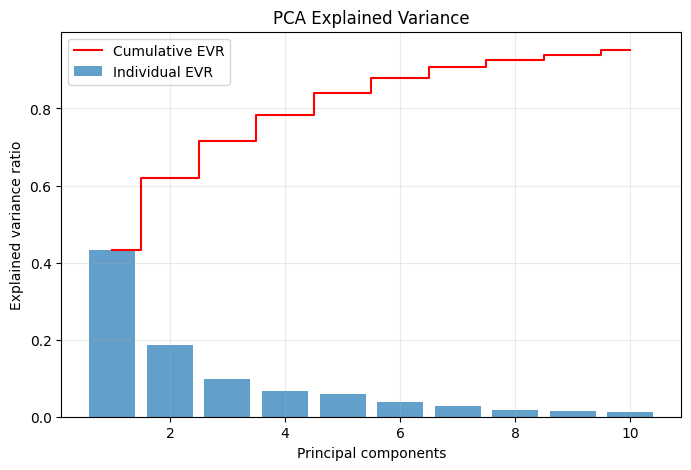

Prepared train shape: (313, 10)
Prepared test shape: (114, 10)


In [8]:
# Data preparation module for Colab
# Block docstrings and @param annotations in English; debug prints in Portuguese.
"""
DataPreparer: prepares data for modeling in a highly-modular, reusable way.

Responsibilities:
- work on a copy of original data (never mutate original)
- implement atomic transformation functions (missing values, outliers, feature selection,
  feature engineering, scaling, PCA)
- expose a sklearn-compatible preprocessing pipeline for reuse in production
- provide fit_transform for train and transform for test / new data

@param inputDataFrame: optional pandas.DataFrame containing the full dataset (if provided, class can split)
@param inputTargetColumnName: optional name of the target column within inputDataFrame
@param preSplit: optional dict with 'X_train','X_test','y_train','y_test' (if you already split earlier)
@param randomState: seed for reproducibility
@return: object with methods to fit/transform and attributes pipeline_, X_train_prepared, X_test_prepared
"""

from typing import Optional, Dict, Any, List, Tuple
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42

class DataPreparer:
    """
    DataPreparer is responsible for cleaning, selecting, engineering and scaling features,
    producing a reusable preprocessing pipeline.

    @param inputDataFrame: original pandas DataFrame (kept intact)
    @param inputTargetColumnName: name of target column if inputDataFrame provided
    @param preSplit: optional dict with pre-split arrays/dataframes: {'X_train','X_test','y_train','y_test'}
    @param randomState: random seed for reproducibility
    """

    def __init__(self,
                 inputDataFrame: Optional[pd.DataFrame] = None,
                 inputTargetColumnName: Optional[str] = None,
                 preSplit: Optional[Dict[str, Any]] = None,
                 randomState: int = RANDOM_STATE):
        print("[AI DEBUG] Initializing DataPreparer")
        self.randomState = randomState
        self.originalDataFrame = inputDataFrame.copy() if inputDataFrame is not None else None
        self.targetColumnName = inputTargetColumnName
        self.pipeline_: Optional[Pipeline] = None
        self.featureNamesAfterProcessing: Optional[List[str]] = None

        # Holders for train/test (may be numpy arrays after transformation)
        self.X_train_raw = None
        self.X_test_raw = None
        self.y_train_raw = None
        self.y_test_raw = None
        self.X_train_prepared = None
        self.X_test_prepared = None

        # small lambdas
        self._is_numeric_series = lambda s: pd.api.types.is_numeric_dtype(s)
        self._safe_div = lambda a, b: a / b if (b is not None and b != 0) else np.nan

        # If user provided pre-split, store it
        if preSplit:
            print("[AI DEBUG] Pre-split data provided; loading splits")
            self.X_train_raw = preSplit.get("X_train")
            self.X_test_raw = preSplit.get("X_test")
            self.y_train_raw = preSplit.get("y_train")
            self.y_test_raw = preSplit.get("y_test")
        print("[AI DEBUG] DataPreparer initialized")

    def createWorkingCopyAndSplitIfNeeded(self, testRatio: float = 0.2, stratifyOnTarget: bool = True) -> None:
        """
        Ensure we have X_train_raw, X_test_raw, y_train_raw, y_test_raw.
        If originalDataFrame is provided, split it here on a copy.

        @param testRatio: fraction for test set
        @param stratifyOnTarget: whether to stratify split when target is categorical
        @return: None (populates the X_*/y_* attributes)
        """
        print("1) Creating working copy and split if necessary")
        if self.X_train_raw is not None:
            print("   Pre-split already available; skipping split.")
            return

        if self.originalDataFrame is None:
            raise ValueError("No data available to split. Provide inputDataFrame or preSplit.")

        df_copy = self.originalDataFrame.copy()
        print(f"   Working copy created with shape: {df_copy.shape}")

        if self.targetColumnName is None or self.targetColumnName not in df_copy.columns:
            # attempt to infer target
            candidates = ['target', 'diagnosis', 'class', 'outcome']
            inferred = next((c for c in candidates if c in df_copy.columns), df_copy.columns[-1])
            self.targetColumnName = inferred
            print(f"   Target column inferred as: {self.targetColumnName}")

        X = df_copy.drop(columns=[self.targetColumnName])
        y = df_copy[self.targetColumnName]
        is_categorical_target = not pd.api.types.is_numeric_dtype(y)

        stratify_arg = y if (is_categorical_target and stratifyOnTarget) else None
        print(f"   Performing train/test split with testRatio={testRatio}, stratify={'yes' if stratify_arg is not None else 'no'}")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=testRatio, random_state=self.randomState, stratify=stratify_arg)

        self.X_train_raw = X_train.reset_index(drop=True)
        self.X_test_raw = X_test.reset_index(drop=True)
        self.y_train_raw = y_train.reset_index(drop=True)
        self.y_test_raw = y_test.reset_index(drop=True)

        print(f"   Split complete: train shape {self.X_train_raw.shape}, test shape {self.X_test_raw.shape}")

    def detectAndOptionallyRemoveOutliers(self, method: str = "iqr", iqrMultiplier: float = 1.5, useIsolationForest: bool = False) -> None:
        """
        Detect (and optionally remove) outliers from the training set only.

        @param method: 'iqr' uses interquartile rule; 'none' disables
        @param iqrMultiplier: multiplier for the IQR rule
        @param useIsolationForest: if True, use IsolationForest for outlier detection
        @return: None (may modify X_train_raw and y_train_raw to remove outlier rows)
        """
        print("2) Detecting and optionally removing outliers")
        if self.X_train_raw is None:
            raise ValueError("X_train_raw not set. Call createWorkingCopyAndSplitIfNeeded() first.")

        numeric_cols = self.X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            print("   No numeric columns found; skipping outlier detection.")
            return

        if useIsolationForest:
            print("   Using IsolationForest for outlier detection")
            iso = IsolationForest(contamination=0.01, random_state=self.randomState)
            preds = iso.fit_predict(self.X_train_raw[numeric_cols])
            mask_inliers = preds == 1
            removed = (~mask_inliers).sum()
            print(f"   IsolationForest flagged {removed} outliers; removing from train set")
            self.X_train_raw = self.X_train_raw.loc[mask_inliers].reset_index(drop=True)
            self.y_train_raw = self.y_train_raw.loc[mask_inliers].reset_index(drop=True)
            return

        if method == "iqr":
            print("   Using IQR rule for outlier detection")
            Q1 = self.X_train_raw[numeric_cols].quantile(0.25)
            Q3 = self.X_train_raw[numeric_cols].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - iqrMultiplier * IQR
            upper_bound = Q3 + iqrMultiplier * IQR
            # build mask of rows that are all within bounds across numeric cols
            mask_inliers = ((self.X_train_raw[numeric_cols] >= lower_bound) & (self.X_train_raw[numeric_cols] <= upper_bound)).all(axis=1)
            removed = (~mask_inliers).sum()
            print(f"   IQR rule would remove {removed} rows from training set")
            # default: do not remove unless user explicitly calls method with removal flag; here we remove
            self.X_train_raw = self.X_train_raw.loc[mask_inliers].reset_index(drop=True)
            self.y_train_raw = self.y_train_raw.loc[mask_inliers].reset_index(drop=True)
            print("   Outliers removed via IQR rule.")
            return

        print("   Outlier detection method set to 'none' or not recognized; skipping.")

    def buildFeatureEngineeringTransformer(self, featureEngineeringChoices: Optional[Dict[str, bool]] = None) -> ColumnTransformer:
        """
        Create a ColumnTransformer that applies feature engineering atomically:
        - numeric imputation
        - custom FunctionTransformer for ratio-like features if the expected columns exist
        - standard scaling afterwards left to outer pipeline

        @param featureEngineeringChoices: dict to toggle particular engineered features
        @return: ColumnTransformer instance (to be used inside a Pipeline)
        """
        print("3) Building feature engineering transformer (atomic functions)")
        featureEngineeringChoices = featureEngineeringChoices or {
            "add_area_perimeter_ratio": True,
            "add_mean_radius_to_mean_perimeter_ratio": True,
            "add_concavity_ratio": True
        }

        numeric_columns = list(self.X_train_raw.select_dtypes(include=[np.number]).columns)
        categorical_columns = list(self.X_train_raw.select_dtypes(exclude=[np.number]).columns)

        # atomic function to compute ratio if both columns exist
        def _make_ratio_transformer(numerator_col: str, denominator_col: str, out_name: str):
            """
            Create a FunctionTransformer that computes ratio numerator/denominator from original X.
            The transformer expects an array with columns in the same order as numeric_columns.
            We will locate column indices at fit-time by wrapping a closure that captures column indices.
            """
            def transformer(X):
                # X is a numpy array with numeric_columns order as we will construct pipeline
                # find indices of numerator and denominator
                num_idx = numeric_columns.index(numerator_col)
                den_idx = numeric_columns.index(denominator_col)
                num = X[:, num_idx]
                den = X[:, den_idx]
                out = np.reshape(np.array([self._safe_div(a, b) for a, b in zip(num, den)]), (-1,1))
                return out
            # Return FunctionTransformer wrapping the closure
            return FunctionTransformer(func=transformer, validate=False)

        transformers_for_featureengineering = []
        # Imputer for numeric defaults
        numeric_imputer = SimpleImputer(strategy="median")
        transformers_for_featureengineering.append(("num_impute", numeric_imputer, numeric_columns))

        # Create ratio transformers only if columns exist
        if featureEngineeringChoices.get("add_area_perimeter_ratio", False):
            # try to find plausible column names
            candidates_area = [c for c in numeric_columns if "area" in c.lower()]
            candidates_perimeter = [c for c in numeric_columns if "perimeter" in c.lower()]
            if candidates_area and candidates_perimeter:
                numerator_col = candidates_area[0]
                denominator_col = candidates_perimeter[0]
                out_name = f"{numerator_col}_to_{denominator_col}_ratio"
                print(f"   Adding engineered feature: {out_name}")
                transformers_for_featureengineering.append((out_name, _make_ratio_transformer(numerator_col, denominator_col, out_name), numeric_columns))
            else:
                print("   Skipping area/perimeter ratio: required columns not found")

        if featureEngineeringChoices.get("add_mean_radius_to_mean_perimeter_ratio", False):
            candidates_radius_mean = [c for c in numeric_columns if "radius" in c.lower() and "mean" in c.lower()]
            candidates_perim_mean = [c for c in numeric_columns if "perimeter" in c.lower() and "mean" in c.lower()]
            if candidates_radius_mean and candidates_perim_mean:
                numerator_col = candidates_radius_mean[0]
                denominator_col = candidates_perim_mean[0]
                out_name = f"{numerator_col}_to_{denominator_col}_ratio"
                print(f"   Adding engineered feature: {out_name}")
                transformers_for_featureengineering.append((out_name, _make_ratio_transformer(numerator_col, denominator_col, out_name), numeric_columns))
            else:
                print("   Skipping mean radius/perimeter ratio: required columns not found")

        # Add placeholder for other FunctionTransformers if needed (e.g., log transforms)
        # log transform for highly skewed numeric columns will be applied after imputation in pipeline via FunctionTransformer
        log_transformer = FunctionTransformer(func=lambda X: np.log1p(X), validate=False)
        # We'll wrap log transform as a separate named transformer to be applied to numeric columns
        transformers_for_featureengineering.append(("log1p_numeric", log_transformer, numeric_columns))

        # For categorical columns, simple imputer + onehot
        categorical_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))
        if categorical_columns:
            print(f"   Categorical columns detected: {categorical_columns}")
        else:
            print("   No categorical columns detected")

        # Build ColumnTransformer
        column_transformer = ColumnTransformer([
            ("num_feats", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_columns),
            ("cat_feats", categorical_pipeline, categorical_columns),
        ], remainder="drop", sparse_threshold=0)

        # We will not return the small custom ratio transformers list because we prefer to insert them as separate steps
        # in the outer pipeline after ColumnTransformer numeric outputs (keeping atomicity).
        self._numeric_columns_order = numeric_columns  # store for later FunctionTransformer closures
        print("   Feature engineering transformer built (base).")
        return column_transformer

    def buildPreprocessingPipeline(self,
                                   usePCA: bool = True,
                                   pcaVarianceThreshold: float = 0.95,
                                   addFeatureEngineeringChoices: Optional[Dict[str,bool]] = None) -> Pipeline:
        """
        Build a complete preprocessing Pipeline: ColumnTransformer -> scaling -> optional PCA -> final transformer.

        @param usePCA: whether to include PCA
        @param pcaVarianceThreshold: if PCA, keep this variance ratio
        @param addFeatureEngineeringChoices: dict toggles for engineered features
        @return: sklearn Pipeline object assigned to self.pipeline_
        """
        print("4) Building preprocessing pipeline (scaling, optional PCA, atomic steps)")
        # Ensure we have raw train data to infer columns
        if self.X_train_raw is None:
            raise ValueError("X_train_raw not set. Call createWorkingCopyAndSplitIfNeeded first.")

        # base column transformer
        base_column_transformer = self.buildFeatureEngineeringTransformer(addFeatureEngineeringChoices)

        # scaler
        scaler = StandardScaler()

        steps = []
        steps.append(("column_transformer", base_column_transformer))
        steps.append(("scaler", scaler))
        if usePCA:
            print(f"   Adding PCA to preserve {pcaVarianceThreshold*100:.0f}% variance")
            pca = PCA(n_components=pcaVarianceThreshold, svd_solver="full", random_state=self.randomState)
            steps.append(("pca", pca))
        pipeline = Pipeline(steps)
        self.pipeline_ = pipeline
        print("   Preprocessing pipeline constructed and stored in self.pipeline_")
        return pipeline

    def fitTransformTrainAndTransformTest(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Fit the pipeline on X_train_raw and transform both train and test sets.

        @return: tuple(X_train_prepared, X_test_prepared) as numpy arrays
        """
        print("5) Fitting preprocessing pipeline on training data and transforming train/test")
        if self.pipeline_ is None:
            raise ValueError("Pipeline not built. Call buildPreprocessingPipeline first.")
        # Fit pipeline on training raw data
        self.X_train_prepared = self.pipeline_.fit_transform(self.X_train_raw)
        print(f"   X_train_prepared shape: {getattr(self.X_train_prepared, 'shape', 'unknown')}")
        # Transform test data
        if self.X_test_raw is not None:
            self.X_test_prepared = self.pipeline_.transform(self.X_test_raw)
            print(f"   X_test_prepared shape: {getattr(self.X_test_prepared, 'shape', 'unknown')}")
        else:
            print("   No X_test_raw available; only X_train_prepared produced.")
        # attempt to store feature names if pipeline provides them
        try:
            # For sklearn >=1.0 get_feature_names_out available at ColumnTransformer level
            feature_names = []
            if hasattr(self.pipeline_.named_steps["column_transformer"], "get_feature_names_out"):
                feature_names = self.pipeline_.named_steps["column_transformer"].get_feature_names_out()
            self.featureNamesAfterProcessing = list(feature_names) if len(feature_names) > 0 else None
            if self.featureNamesAfterProcessing:
                print(f"   Feature names after processing (sample): {self.featureNamesAfterProcessing[:10]}")
        except Exception:
            pass
        return self.X_train_prepared, self.X_test_prepared

    def plotPCAExplainedVariance(self, n_components_to_plot: int = 20) -> None:
        """
        Plot explained variance ratio if PCA present in pipeline.

        @param n_components_to_plot: how many components to visualize
        """
        print("6) Plotting PCA explained variance (if PCA present in pipeline)")
        if self.pipeline_ is None or "pca" not in self.pipeline_.named_steps:
            print("   PCA not present in pipeline; skipping plot.")
            return
        pca = self.pipeline_.named_steps["pca"]
        evr = pca.explained_variance_ratio_
        cum_evr = np.cumsum(evr)
        n = min(len(evr), n_components_to_plot)
        plt.figure(figsize=(8,5))
        plt.bar(range(1, n+1), evr[:n], alpha=0.7, label="Individual EVR")
        plt.step(range(1, n+1), cum_evr[:n], where='mid', color="red", label="Cumulative EVR")
        plt.xlabel("Principal components")
        plt.ylabel("Explained variance ratio")
        plt.title("PCA Explained Variance")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.show()

    def savePipeline(self, outputPath: str) -> None:
        """
        Persist the fitted pipeline to disk using joblib.

        @param outputPath: destination filepath (e.g., 'models/preprocessing.pkl')
        """
        import joblib
        print(f"7) Saving pipeline to disk at {outputPath}")
        if self.pipeline_ is None:
            raise ValueError("No pipeline to save. Build and fit the pipeline first.")
        Path(outputPath).parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(self.pipeline_, outputPath)
        print("   Pipeline saved successfully.")

    def loadPipeline(self, inputPath: str) -> None:
        """
        Load a persisted pipeline into self.pipeline_.

        @param inputPath: path to joblib file
        """
        import joblib
        print(f"   Loading pipeline from {inputPath}")
        self.pipeline_ = joblib.load(inputPath)
        print("   Pipeline loaded.")

# Example usage (Colab)
if __name__ == "__main__":
    # Suppose you used the earlier DataManager to obtain manager.dataFrame and manager.targetVariable
    # Example quick demo using sklearn fallback data:
    from sklearn.datasets import load_breast_cancer
    payload = load_breast_cancer()
    demo_df = pd.DataFrame(payload.data, columns=[c.replace(" ", "_") for c in payload.feature_names])
    demo_df["target"] = payload.target

    preparer = DataPreparer(inputDataFrame=demo_df, inputTargetColumnName="target", randomState=RANDOM_STATE)
    preparer.createWorkingCopyAndSplitIfNeeded(testRatio=0.2)
    preparer.detectAndOptionallyRemoveOutliers(method="iqr", iqrMultiplier=1.5, useIsolationForest=False)
    preparer.buildPreprocessingPipeline(usePCA=True, pcaVarianceThreshold=0.95)
    X_train_prep, X_test_prep = preparer.fitTransformTrainAndTransformTest()
    preparer.plotPCAExplainedVariance(n_components_to_plot=15)

    print("Prepared train shape:", getattr(X_train_prep, "shape", None))
    print("Prepared test shape:", getattr(X_test_prep, "shape", None))


[AI DEBUG] Inicializando ModelShortlister
[AI DEBUG] Definindo catálogo de modelos candidatos (parâmetros padrão)
1. Treinando modelos rápidos de diferentes categorias com parâmetros padrão
[AI DEBUG] Treinando e avaliando: LogisticRegression
   Modelo LogisticRegression treinado no conjunto de treino
   CV (5-fold) accuracy: mean=0.9429, std=0.0189
   Test accuracy: 0.9649, F1: 0.9722
[AI DEBUG] Treinando e avaliando: SVC
   Modelo SVC treinado no conjunto de treino
   CV (5-fold) accuracy: mean=0.9099, std=0.0290
   Test accuracy: 0.9298, F1: 0.9459
[AI DEBUG] Treinando e avaliando: RandomForest
   Modelo RandomForest treinado no conjunto de treino
   CV (5-fold) accuracy: mean=0.9538, std=0.0235
   Test accuracy: 0.9561, F1: 0.9655
   Feature importances (top 5): [('feat_23', np.float64(0.14001598566310833)), ('feat_27', np.float64(0.12952961280106504)), ('feat_20', np.float64(0.09769573685350633)), ('feat_7', np.float64(0.0908847484687512)), ('feat_22', np.float64(0.072226370069889

,Model,CV_Mean,CV_Std,Test_Accuracy,Test_F1,Test_ROC_AUC
0,GradientBoosting,0.9560,0.0139,0.9561,0.9660,0.9907
1,RandomForest,0.9538,0.0235,0.9561,0.9655,0.9937
2,LogisticRegression,0.9429,0.0189,0.9649,0.9722,0.9960
3,MLP,0.9407,0.0179,0.9211,0.9388,0.9821
4,GaussianNB,0.9363,0.0044,0.9386,0.9517,0.9878
5,KNN,0.9363,0.0189,0.9123,0.9296,0.9559
6,SVC,0.9099,0.0290,0.9298,0.9459,0.9696
7,DecisionTree,0.9099,0.0189,0.9123,0.9286,0.9157


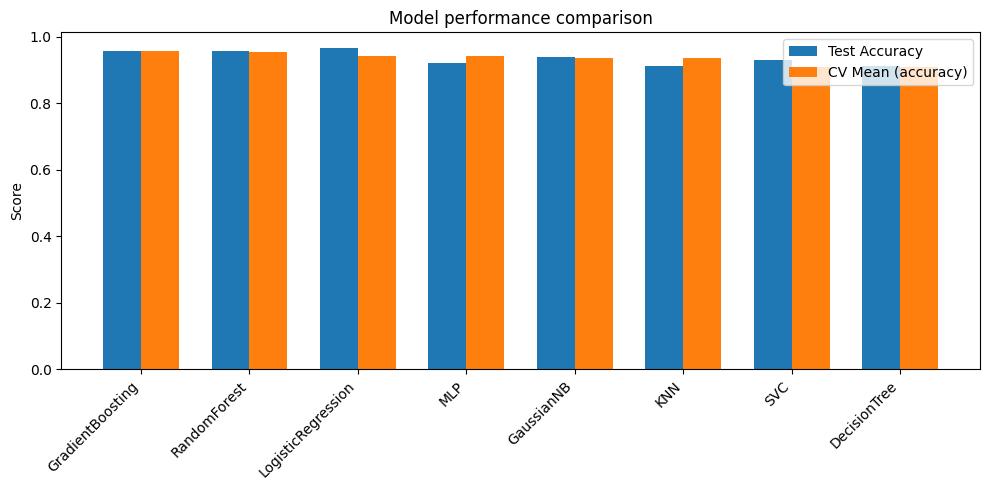


3. Modelos mais promissores selecionados:
   Top 3: ['GradientBoosting', 'RandomForest', 'LogisticRegression']
[AI DEBUG] Analisando erros do modelo: GradientBoosting
   Confusion matrix (true x pred):
[[38  4]
 [ 1 71]]


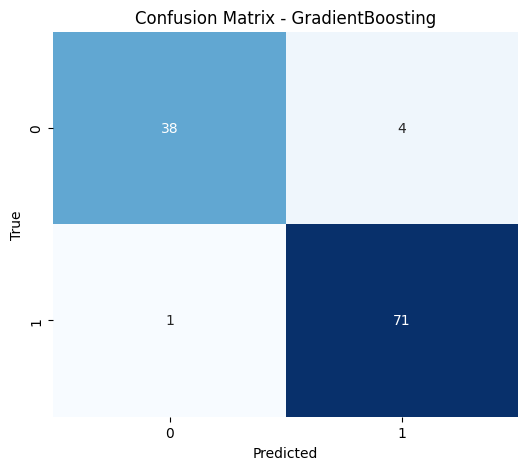

   Classification report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

   False negatives: 1, False positives: 4
   Insight: model favors recall over precision; consider precision-focused tuning or stricter threshold.
Top models keys: ['GradientBoosting', 'RandomForest', 'LogisticRegression']


In [9]:
# Model shortlisting module for Colab
# English block docstrings and @param annotations; debug prints in Portuguese.

"""
ModelShortlister: trains multiple quick models, evaluates them with cross-validation and test set,
analyzes feature importance for tree models, inspects error types, and shortlists top candidates.

@param X_train: numpy array or pandas DataFrame with training features
@param X_test: numpy array or pandas DataFrame with test features
@param y_train: numpy array or pandas Series with training labels
@param y_test: numpy array or pandas Series with test labels
@param nFolds: int number of CV folds used for cross-validation
@param randomState: int seed for reproducibility
@return: populates .results_df and .top_models attributes
"""

from typing import Optional, Dict, Any, List, Tuple, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

class ModelShortlister:
    """
    Shortlist promising classification models using quick-and-dirty training and evaluation.

    @param X_train: training features (np.ndarray or pd.DataFrame)
    @param X_test: test features (np.ndarray or pd.DataFrame)
    @param y_train: training labels (np.ndarray or pd.Series)
    @param y_test: test labels (np.ndarray or pd.Series)
    @param nFolds: number of CV folds (default 5)
    @param randomState: random seed for reproducibility
    """
    def __init__(self,
                 X_train: Union[np.ndarray, pd.DataFrame],
                 X_test: Union[np.ndarray, pd.DataFrame],
                 y_train: Union[np.ndarray, pd.Series],
                 y_test: Union[np.ndarray, pd.Series],
                 nFolds: int = 5,
                 randomState: int = 42):
        print("[AI DEBUG] Inicializando ModelShortlister")
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = self._ensure_numpy_array(y_train)
        self.y_test = self._ensure_numpy_array(y_test)
        self.nFolds = nFolds
        self.randomState = randomState

        self.models_catalog = self._defineCandidateModels()
        self.results: List[Dict[str, Any]] = []
        self.results_df: Optional[pd.DataFrame] = None
        self.top_models: Dict[str, Any] = {}
        # small lambdas
        self._safe_roc_auc = lambda clf, X, y: (roc_auc_score(y, clf.predict_proba(X)[:,1]) if hasattr(clf, "predict_proba") else (roc_auc_score(y, clf.decision_function(X)) if hasattr(clf, "decision_function") else np.nan))

    def _ensure_numpy_array(self, y: Union[np.ndarray, pd.Series]) -> np.ndarray:
        """Ensure labels are numpy array"""
        if isinstance(y, pd.Series):
            return y.values
        if isinstance(y, np.ndarray):
            return y
        # try to convert
        return np.asarray(y)

    def _ensure_feature_names(self) -> List[str]:
        """Return feature names if X_train is a DataFrame, otherwise synthetic names"""
        if isinstance(self.X_train, pd.DataFrame):
            return list(self.X_train.columns)
        # if numpy, create generic names
        n_feats = self.X_train.shape[1] if hasattr(self.X_train, "shape") else None
        return [f"feat_{i}" for i in range(n_feats)] if n_feats else []

    def _defineCandidateModels(self) -> Dict[str, Any]:
        """Define a dictionary of candidate models with sensible default params"""
        print("[AI DEBUG] Definindo catálogo de modelos candidatos (parâmetros padrão)")
        models = {
            "LogisticRegression": LogisticRegression(random_state=self.randomState, max_iter=1000),
            "SVC": SVC(random_state=self.randomState, probability=True),
            "RandomForest": RandomForestClassifier(random_state=self.randomState),
            "GradientBoosting": GradientBoostingClassifier(random_state=self.randomState),
            "KNN": KNeighborsClassifier(),
            "DecisionTree": DecisionTreeClassifier(random_state=self.randomState),
            "GaussianNB": GaussianNB(),
            "MLP": MLPClassifier(random_state=self.randomState, max_iter=500)
        }
        return models

    def _evaluateOnTestSet(self, model, X_test, y_test) -> Dict[str, Any]:
        """Compute standard metrics on test set"""
        y_pred = model.predict(X_test)
        try:
            y_proba_available = hasattr(model, "predict_proba") or hasattr(model, "decision_function")
        except Exception:
            y_proba_available = False
        metrics = {
            "accuracy": float(accuracy_score(y_test, y_pred)),
            "precision": float(precision_score(y_test, y_pred, zero_division=0)),
            "recall": float(recall_score(y_test, y_pred, zero_division=0)),
            "f1": float(f1_score(y_test, y_pred, zero_division=0)),
            "roc_auc": float(self._safe_roc_auc(model, X_test, y_test)) if y_proba_available else np.nan,
            "confusion_matrix": confusion_matrix(y_test, y_pred),
            "classification_report": classification_report(y_test, y_pred, zero_division=0, output_dict=True)
        }
        return metrics

    def _crossValidateModel(self, model, X, y, scoring: str = "accuracy") -> Tuple[float, float]:
        """Run cross_val_score and return mean and std"""
        try:
            cv_scores = cross_val_score(model, X, y, cv=self.nFolds, scoring=scoring)
            return float(np.mean(cv_scores)), float(np.std(cv_scores))
        except Exception as exc:
            print(f"[AI DEBUG] cross_val_score failed for scoring={scoring}: {exc}, falling back to accuracy")
            cv_scores = cross_val_score(model, X, y, cv=self.nFolds, scoring="accuracy")
            return float(np.mean(cv_scores)), float(np.std(cv_scores))

    def trainAndShortlist(self, primaryScoring: str = "accuracy", topK: int = 3) -> pd.DataFrame:
        """
        Train all candidate models quickly on train set, evaluate by CV and test set,
        and shortlist topK models by CV mean on primaryScoring.

        @param primaryScoring: metric used to rank models (default 'accuracy')
        @param topK: number of top models to shortlist
        @return: results DataFrame sorted by CV mean descending
        """
        print("1. Treinando modelos rápidos de diferentes categorias com parâmetros padrão")
        feature_names = self._ensure_feature_names()
        X_train_for_cv = self.X_train if isinstance(self.X_train, (np.ndarray, pd.DataFrame)) else np.asarray(self.X_train)
        y_train_for_cv = self.y_train

        for model_name, model_obj in self.models_catalog.items():
            print(f"[AI DEBUG] Treinando e avaliando: {model_name}")
            try:
                # clone model to avoid cross contamination
                from sklearn.base import clone
                model_clone = clone(model_obj)
                model_clone.random_state = getattr(model_clone, "random_state", self.randomState)

                # fit on training data
                model_clone.fit(self.X_train, self.y_train)
                print(f"   Modelo {model_name} treinado no conjunto de treino")

                # cross-validation on training set
                cv_mean, cv_std = self._crossValidateModel(model_clone, X_train_for_cv, y_train_for_cv, scoring=primaryScoring)
                print(f"   CV ({self.nFolds}-fold) {primaryScoring}: mean={cv_mean:.4f}, std={cv_std:.4f}")

                # evaluate on test set
                test_metrics = self._evaluateOnTestSet(model_clone, self.X_test, self.y_test)
                print(f"   Test accuracy: {test_metrics['accuracy']:.4f}, F1: {test_metrics['f1']:.4f}")

                # feature importance where applicable
                feature_importances = None
                if hasattr(model_clone, "feature_importances_"):
                    fi = getattr(model_clone, "feature_importances_")
                    # map to feature names if available
                    names = feature_names if feature_names else [f"feat_{i}" for i in range(len(fi))]
                    feature_importances = sorted(zip(names, fi), key=lambda x: x[1], reverse=True)
                    print(f"   Feature importances (top 5): {feature_importances[:5]}")

                # store results
                record = {
                    "Model": model_name,
                    "CV_Mean": cv_mean,
                    "CV_Std": cv_std,
                    "Test_Accuracy": test_metrics["accuracy"],
                    "Test_Precision": test_metrics["precision"],
                    "Test_Recall": test_metrics["recall"],
                    "Test_F1": test_metrics["f1"],
                    "Test_ROC_AUC": test_metrics["roc_auc"],
                    "Feature_Importances": feature_importances,
                    "Confusion_Matrix": test_metrics["confusion_matrix"],
                    "Classification_Report": test_metrics["classification_report"],
                    "Fitted_Model": model_clone
                }
                self.results.append(record)
            except Exception as exc:
                print(f"[AI DEBUG] Falha ao treinar/avaliar {model_name}: {exc}")
                continue

        # Build results DataFrame
        self.results_df = pd.DataFrame([{
            "Model": r["Model"],
            "CV_Mean": r["CV_Mean"],
            "CV_Std": r["CV_Std"],
            "Test_Accuracy": r["Test_Accuracy"],
            "Test_F1": r["Test_F1"],
            "Test_ROC_AUC": r["Test_ROC_AUC"]
        } for r in self.results]).sort_values(by="CV_Mean", ascending=False).reset_index(drop=True)

        print("\n2. Medindo e comparando performance: resultados sumarizados")
        display(self.results_df.style.format({c: "{:.4f}" for c in ["CV_Mean","CV_Std","Test_Accuracy","Test_F1","Test_ROC_AUC"]}))

        # Plot comparison charts
        try:
            plt.figure(figsize=(10,5))
            width = 0.35
            idx = np.arange(len(self.results_df))
            plt.bar(idx - width/2, self.results_df["Test_Accuracy"], width=width, label="Test Accuracy")
            plt.bar(idx + width/2, self.results_df["CV_Mean"], width=width, label=f"CV Mean ({primaryScoring})")
            plt.xticks(idx, self.results_df["Model"], rotation=45, ha="right")
            plt.ylabel("Score")
            plt.title("Model performance comparison")
            plt.legend()
            plt.tight_layout()
            plt.show()
        except Exception as exc:
            print(f"[AI DEBUG] Falha ao plotar comparação: {exc}")

        # shortlist topK models
        top_models_list = self.results_df.head(topK)["Model"].tolist()
        self.top_models = {name: next((r["Fitted_Model"] for r in self.results if r["Model"] == name), None) for name in top_models_list}

        print("\n3. Modelos mais promissores selecionados:")
        print(f"   Top {topK}: {top_models_list}")
        return self.results_df

    def analyzeBestModelErrors(self, modelName: Optional[str] = None) -> None:
        """
        Show confusion matrix, classification report and type-of-error analysis for the chosen model.

        @param modelName: name of the already shortlisted model (if None uses best CV mean)
        """
        if self.results_df is None or self.results_df.empty:
            raise ValueError("No results available. Run trainAndShortlist first.")

        chosen = modelName or self.results_df.iloc[0]["Model"]
        print(f"[AI DEBUG] Analisando erros do modelo: {chosen}")
        fitted = next((r["Fitted_Model"] for r in self.results if r["Model"] == chosen), None)
        if fitted is None:
            print("[AI DEBUG] Modelo não encontrado ou não treinado.")
            return

        y_pred = fitted.predict(self.X_test)
        cm = confusion_matrix(self.y_test, y_pred)
        print("   Confusion matrix (true x pred):")
        print(cm)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix - {chosen}")
        plt.show()

        print("   Classification report:")
        cr = classification_report(self.y_test, y_pred, zero_division=0)
        print(cr)

        # Simple human-guided insight generation: false negatives vs false positives count
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (None,)*4
        if tp is not None:
            print(f"   False negatives: {fn}, False positives: {fp}")
            if fn > fp:
                print("   Insight: model favors precision over recall; consider recall-focused tuning (class_weight or threshold).")
            elif fp > fn:
                print("   Insight: model favors recall over precision; consider precision-focused tuning or stricter threshold.")
            else:
                print("   Insight: false negatives and false positives balanced for this threshold.")

    def getTopModels(self) -> Dict[str, Any]:
        """Return the shortlisted fitted model objects"""
        return self.top_models

# Example usage (after data is prepared)
if __name__ == "__main__":
    # assume preparer from previous block produced X_train_prep, X_test_prep, and y_train/y_test exist
    # Use demo with sklearn dataset if not available
    from sklearn.datasets import load_breast_cancer
    payload = load_breast_cancer()
    demo_df = pd.DataFrame(payload.data, columns=[c.replace(" ", "_") for c in payload.feature_names])
    demo_df["target"] = payload.target
    X = demo_df.drop(columns=["target"]).values
    y = demo_df["target"].values
    from sklearn.model_selection import train_test_split
    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    shortlister = ModelShortlister(X_train_d, X_test_d, y_train_d, y_test_d, nFolds=5, randomState=42)
    results = shortlister.trainAndShortlist(primaryScoring="accuracy", topK=3)
    shortlister.analyzeBestModelErrors()  # analyzes the top model
    top_models = shortlister.getTopModels()
    print("Top models keys:", list(top_models.keys()))


In [12]:
# FineTuner module for Colab
# Block docstring in English with @param; debug prints in Portuguese

"""
FineTuner: fine-tune candidate models (optionally including preprocessing hyperparameters),
build ensembles and evaluate final models on the test set.

@param preprocessingPipeline: sklearn Transformer or Pipeline used to preprocess data (can be None)
@param candidateModelsDict: dict mapping modelName -> sklearn estimator (unfitted)
@param X_train: training features (np.ndarray or pd.DataFrame)
@param X_test: test features (np.ndarray or pd.DataFrame)
@param y_train: training labels (np.ndarray or pd.Series)
@param y_test: numpy array or pandas Series with test labels
@param randomState: int seed for reproducibility
@param nJobs: int number of parallel jobs for searches
@return: object with methods tuneAllModels(), buildEnsemble(), evaluateModels(), persistBestModel()
"""

from typing import Optional, Dict, Any, List, Tuple, Union
import numpy as np
import pandas as pd
import inspect
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.experimental import enable_halving_search_cv # Import required for HalvingRandomSearchCV
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from scipy.stats import randint, uniform
from sklearn.base import clone

warnings.filterwarnings("ignore")

class FineTuner:
    """
    FineTuner orchestrates hyperparameter search, ensemble creation and final evaluation.

    @param preprocessingPipeline: sklearn Transformer/ColumnTransformer/Pipeline (or None)
    @param candidateModelsDict: dict of {modelName: estimator}
    @param X_train: training features
    @param X_test: test features
    @param y_train: training labels
    @param y_test: test labels
    @param randomState: seed
    @param nJobs: parallel jobs for search
    """
    def __init__(self,
                 preprocessingPipeline: Optional[Pipeline],
                 candidateModelsDict: Dict[str, Any],
                 X_train: Union[np.ndarray, pd.DataFrame],
                 X_test: Union[np.ndarray, pd.DataFrame],
                 y_train: Union[np.ndarray, pd.Series],
                 y_test: Union[np.ndarray, pd.Series],
                 randomState: int = 42,
                 nJobs: int = -1):
        print("[AI DEBUG] Inicializando FineTuner")
        self.preprocessingPipeline = preprocessingPipeline
        self.candidateModelsDict = candidateModelsDict.copy()
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = np.asarray(y_train)
        self.y_test = np.asarray(y_test)
        self.randomState = randomState
        self.nJobs = nJobs

        self.tunedModels: Dict[str, Any] = {}
        self.tuningReports: Dict[str, Any] = {}
        self.finalResults: Optional[pd.DataFrame] = None

        # lambdas for safe metrics
        self._safe_roc_auc = lambda m, X, y: (roc_auc_score(y, m.predict_proba(X)[:,1]) if hasattr(m, "predict_proba") else (roc_auc_score(y, m.decision_function(X)) if hasattr(m, "decision_function") else np.nan))
        self._metric_dict = lambda y_true, y_pred, model_obj=None: {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "roc_auc": float(self._safe_roc_auc(model_obj, self.X_test, y_true)) if model_obj is not None else np.nan
        }

        print("[AI DEBUG] FineTuner ready")

    def _makePipelineForEstimator(self, estimator) -> Pipeline:
        """
        Return a Pipeline that wraps preprocessing (if given) and estimator.

        @param estimator: sklearn estimator
        @return: Pipeline object
        """
        if self.preprocessingPipeline is not None:
            return Pipeline([("preprocessing", self.preprocessingPipeline), ("estimator", estimator)])
        return Pipeline([("estimator", estimator)])

    def _filterParamDistributions(self, pipelineObj: Pipeline, param_distributions: Dict[str, Any]) -> Dict[str, Any]:
        """
        Keep only parameter keys that exist in pipelineObj.get_params().keys().

        @param pipelineObj: Pipeline to validate parameter names against
        @param param_distributions: proposed dict of param distributions
        @return: filtered dict with only valid keys
        """
        valid_keys = set(pipelineObj.get_params().keys())
        filtered = {k: v for k, v in param_distributions.items() if k in valid_keys}
        dropped = [k for k in param_distributions.keys() if k not in filtered]
        if dropped:
            print(f"[AI DEBUG] Removed invalid hyperparam keys for this pipeline: {dropped}")
        return filtered

    def defineDefaultParamDistributions(self) -> Dict[str, Dict[str, Any]]:
        """
        Return a default set of hyperparameter distributions for common models
        and some preprocessing knobs. The keys are intended to be adapted to the
        pipeline structure; invalid keys will be filtered later.

        @return: dict modelName -> param_distributions (with pipeline-prefixed keys)
        """
        print("[AI DEBUG] Building default hyperparameter distributions (will be filtered against actual pipeline params)")
        common_preproc_space = {
            # common preprocessing knobs - these keys may or may not exist depending on pipeline implementation
            # Examples using scikit-learn default naming conventions:
            "preprocessing__column_transformer__num_feats__imputer__strategy": ["median", "mean"],
            "preprocessing__scaler__with_mean": [True, False],
            "preprocessing__pca__n_components": uniform(0.5, 0.5),  # sample continuous in (0.5, 1.0)
        }
        # Define log_uniform before use
        log_uniform = uniform(0.001, 1000)
        model_spaces = {
            "LogisticRegression": {
                "estimator__C": log_uniform,  # use as continuous log-uniform proxy
                "estimator__solver": ["lbfgs", "liblinear", "saga"],
                "estimator__penalty": ["l2"],
            },
            "RandomForest": {
                "estimator__n_estimators": randint(50, 300),
                "estimator__max_depth": [None, 5, 10, 20, 40],
                "estimator__min_samples_split": randint(2, 11),
                "estimator__min_samples_leaf": randint(1, 6),
                "estimator__max_features": ["sqrt", "log2", None]
            },
            "SVC": {
                "estimator__C": log_uniform,
                "estimator__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
                "estimator__kernel": ["rbf", "linear"]
            },
            "GradientBoosting": {
                "estimator__n_estimators": randint(50, 300),
                "estimator__learning_rate": uniform(0.01, 0.3),
                "estimator__max_depth": randint(2, 10)
            },
            "MLP": {
                "estimator__hidden_layer_sizes": [(50,), (100,), (100,50)],
                "estimator__alpha": uniform(1e-6, 1e-2),
                "estimator__learning_rate_init": uniform(1e-4, 1e-1)
            }
        }
        # merge common preprocessing options into each model space (under the assumption preprocessing key names exist)
        for name in list(model_spaces.keys()):
            merged = {}
            merged.update(common_preproc_space)
            merged.update(model_spaces[name])
            model_spaces[name] = merged
        print("[AI DEBUG] Default hyperparameter distributions assembled")
        return model_spaces

    def tuneModel(self,
                  modelName: str,
                  estimator,
                  param_distributions: Optional[Dict[str, Any]] = None,
                  nIter: int = 30,
                  cvFolds: int = 5,
                  scoring: str = "accuracy",
                  useHalving: bool = False) -> Tuple[Any, Dict[str, Any]]:
        """
        Tune a single model using RandomizedSearchCV (or HalvingRandomSearchCV if requested).
        The search will be executed on a Pipeline that wraps preprocessing (if present) and the estimator.

        @param modelName: name string for logging
        @param estimator: sklearn estimator (unfitted)
        @param param_distributions: dict of param distributions (pipeline-prefixed keys)
        @param nIter: number of random parameter settings to sample
        @param cvFolds: CV folds
        @param scoring: scoring metric for search
        @param useHalving: whether to use iterative halving randomized search
        @return: tuple(best_estimator_pipeline, report dict)
        """
        print(f"\n[AI DEBUG] Tunando modelo: {modelName}")
        pipeline_obj = self._makePipelineForEstimator(estimator)
        param_distributions = param_distributions or {}
        # filter param keys to those actually accepted by the pipeline
        filtered_param_distributions = self._filterParamDistributions(pipeline_obj, param_distributions)
        # if no params left, warn and perform a quick fit-only baseline
        if not filtered_param_distributions:
            print("[AI DEBUG] Nenhuma hiperparâmetro válido para busca; treinando modelo padrão sem tuning")
            pipeline_obj.fit(self.X_train, self.y_train)
            report = {"note": "no_valid_hyperparameters; baseline trained", "cv_results": None}
            return pipeline_obj, report

        # choose searcher
        searcher = None
        if useHalving:
            print("[AI DEBUG] Using HalvingRandomSearchCV (iterative, resource-efficient)")
            searcher = HalvingRandomSearchCV(estimator=pipeline_obj,
                                            param_distributions=filtered_param_distributions,
                                            n_candidates="exhaust",
                                            factor=3,
                                            cv=cvFolds,
                                            scoring=scoring,
                                            random_state=self.randomState,
                                            n_jobs=self.nJobs)
        else:
            searcher = RandomizedSearchCV(estimator=pipeline_obj,
                                         param_distributions=filtered_param_distributions,
                                         n_iter=nIter,
                                         cv=cvFolds,
                                         scoring=scoring,
                                         random_state=self.randomState,
                                         n_jobs=self.nJobs,
                                         return_train_score=False)
        # execute search
        searcher.fit(self.X_train, self.y_train)
        best = searcher.best_estimator_
        report = {
            "best_params": searcher.best_params_,
            "best_score": float(searcher.best_score_),
            "cv_results": searcher.cv_results_
        }
        print(f"[AI DEBUG] Tuning complete for {modelName}: best_score={report['best_score']:.4f}")
        # store tuned pipeline (pipeline includes preprocessing + estimator)
        self.tunedModels[modelName] = best
        self.tuningReports[modelName] = report
        return best, report

    def tuneAllModels(self,
                      paramDistributionOverrides: Optional[Dict[str, Dict[str, Any]]] = None,
                      nIter: int = 30,
                      cvFolds: int = 5,
                      scoring: str = "accuracy",
                      useHalving: bool = False) -> Dict[str, Dict[str, Any]]:
        """
        Tune all candidate models. Uses default parameter spaces unless overrides are provided.

        @param paramDistributionOverrides: optional dict modelName -> param_distributions to override defaults
        @param nIter: number of iterations for RandomizedSearchCV
        @param cvFolds: CV folds
        @param scoring: scoring for tuning
        @param useHalving: whether to use HalvingRandomSearchCV
        @return: tuningReports dict
        """
        print("[AI DEBUG] Iniciando tuning de todos os modelos candidatos")
        default_spaces = self.defineDefaultParamDistributions()
        for modelName, estimator in self.candidateModelsDict.items():
            space = paramDistributionOverrides.get(modelName) if (paramDistributionOverrides and modelName in paramDistributionOverrides) else default_spaces.get(modelName, {})
            try:
                self.tuneModel(modelName, estimator, param_distributions=space, nIter=nIter, cvFolds=cvFolds, scoring=scoring, useHalving=useHalving)
            except Exception as exc:
                print(f"[AI DEBUG] Falha no tuning do modelo {modelName}: {exc}")
                # fallback: train baseline without tuning
                baseline_pipeline = self._makePipelineForEstimator(estimator)
                baseline_pipeline.fit(self.X_train, self.y_train)
                self.tunedModels[modelName] = baseline_pipeline
                self.tuningReports[modelName] = {"note": f"fallback trained due to error: {exc}"}
        print("[AI DEBUG] Tuning completo para todos os modelos")
        return self.tuningReports

    def buildEnsemble(self, ensembleType: str = "voting", voting: str = "soft", stack_final_estimator: Optional[Any] = None) -> Any:
        """
        Build an ensemble from tunedModels. Supports 'voting' and 'stacking'.

        @param ensembleType: 'voting' or 'stacking'
        @param voting: for VotingClassifier ('soft' or 'hard')
        @param stack_final_estimator: optional final estimator for stacking
        @return: ensemble estimator (fitted)
        """
        print(f"[AI DEBUG] Construindo ensemble do tipo: {ensembleType}")
        if len(self.tunedModels) < 2:
            raise ValueError("At least two tuned models required to build an ensemble")

        estimators_list = [(name, mdl.named_steps["estimator"] if isinstance(mdl, Pipeline) else mdl) for name, mdl in self.tunedModels.items()]

        # In voting/stacking we want estimators without preprocessing step repeated.
        # We'll create a single pipeline: preprocessing -> ensemble(estimator_wrapped)
        if self.preprocessingPipeline is not None:
            # wrap each tuned estimator into a clone (estimator only)
            estimators_for_ensemble = []
            for name, mdl in self.tunedModels.items():
                est = mdl.named_steps["estimator"] if isinstance(mdl, Pipeline) else clone(mdl)
                estimators_for_ensemble.append((name, est))
            if ensembleType == "voting":
                ensemble_body = VotingClassifier(estimators=estimators_for_ensemble, voting=voting, n_jobs=self.nJobs)
            else:
                final_est = stack_final_estimator or estimators_for_ensemble[-1][1]
                ensemble_body = StackingClassifier(estimators=estimators_for_ensemble, final_estimator=final_est, n_jobs=self.nJobs, passthrough=False)
            # full pipeline: preprocessing + ensemble_body
            ensemble_pipeline = Pipeline([("preprocessing", clone(self.preprocessingPipeline)), ("ensemble", ensemble_body)])
            ensemble_pipeline.fit(self.X_train, self.y_train)
            self.tunedModels["Ensemble"] = ensemble_pipeline
            print("[AI DEBUG] Ensemble construído e treinado com preprocessing pipeline")
            return ensemble_pipeline
        else:
            # No preprocessing pipeline present: ensemble directly on raw arrays
            if ensembleType == "voting":
                ensemble_body = VotingClassifier(estimators=estimators_list, voting=voting, n_jobs=self.nJobs)
            else:
                final_est = stack_final_estimator or estimators_list[-1][1]
                ensemble_body = StackingClassifier(estimators=estimators_list, final_estimator=final_est, n_jobs=self.nJobs, passthrough=False)
            ensemble_body.fit(self.X_train, self.y_train)
            self.tunedModels["Ensemble"] = ensemble_body
            print("[AI DEBUG] Ensemble construído e treinado (sem preprocessing pipeline)")
            return ensemble_body

    def evaluateModels(self, modelsToEvaluate: Optional[Dict[str, Any]] = None) -> pd.DataFrame:
        """
        Evaluate models (tunedModels by default) on the test set and return a DataFrame of metrics.

        @param modelsToEvaluate: optional dict modelName->estimator to evaluate instead of self.tunedModels
        @return: pandas.DataFrame with evaluation metrics
        """
        print("[AI DEBUG] Avaliando modelos no conjunto de teste")
        models = modelsToEvaluate or self.tunedModels
        rows = []
        for name, pipeline_or_est in models.items():
            try:
                # pipeline_or_est may be a Pipeline(preprocessing+estimator) or estimator alone
                pred = pipeline_or_est.predict(self.X_test)
                metrics = self._metric_dict(self.y_test, pred, pipeline_or_est)
                rows.append({
                    "Model": name,
                    "Accuracy": metrics["accuracy"],
                    "Precision": metrics["precision"],
                    "Recall": metrics["recall"],
                    "F1": metrics["f1"],
                    "ROC_AUC": metrics["roc_auc"]
                })
                print(f"   {name}: Accuracy={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}")
            except Exception as exc:
                print(f"[AI DEBUG] Falha ao avaliar {name}: {exc}")
                rows.append({"Model": name, "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": np.nan, "ROC_AUC": np.nan})
        df = pd.DataFrame(rows).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
        self.finalResults = df
        display(df.style.format({c: "{:.4f}" for c in ["Accuracy","Precision","Recall","F1","ROC_AUC"]}))
        return df

    def persistBestModel(self, outputPath: str) -> None:
        """
        Persist the best performing model (by Accuracy on test set) using joblib.

        @param outputPath: file path to save model
        """
        import joblib
        if self.finalResults is None or self.finalResults.empty:
            raise ValueError("No evaluation results. Run evaluateModels() first.")
        best_name = self.finalResults.iloc[0]["Model"]
        best_obj = self.tunedModels.get(best_name)
        if best_obj is None:
            raise ValueError(f"Best model {best_name} not found among tunedModels")
        joblib.dump(best_obj, outputPath)
        print(f"[AI DEBUG] Best model '{best_name}' persisted to {outputPath}")

# Example usage (after ModelShortlister produced top_models or after you have candidateModels)
if __name__ == "__main__":
    # Quick demo using sklearn breast cancer dataset and simple candidate models
    from sklearn.datasets import load_breast_cancer
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import make_pipeline
    payload = load_breast_cancer()
    demo_df = pd.DataFrame(payload.data, columns=[c.replace(" ", "_") for c in payload.feature_names])
    demo_df["target"] = payload.target
    X = demo_df.drop(columns=["target"]).values
    y = demo_df["target"].values
    from sklearn.model_selection import train_test_split
    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # define a simple preprocessing pipeline (optional)
    preprocessing_demo = make_pipeline(StandardScaler())

    candidate_models = {
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "RandomForest": RandomForestClassifier(random_state=42)
    }

    tuner = FineTuner(preprocessingPipeline=preprocessing_demo,
                      candidateModelsDict=candidate_models,
                      X_train=X_train_d, X_test=X_test_d,
                      y_train=y_train_d, y_test=y_test_d,
                      randomState=42, nJobs=2)

    # tune all models (this may take some time)
    tuner.tuneAllModels(nIter=20, cvFolds=3, scoring="accuracy", useHalving=False)

    # build voting ensemble from tuned models
    if len(tuner.tunedModels) >= 2:
        tuner.buildEnsemble(ensembleType="voting", voting="soft")

    # evaluate all (including ensemble if present)
    tuner.evaluateModels()

    # persist best model
    tuner.persistBestModel("best_model_pipeline.joblib")

[AI DEBUG] Inicializando FineTuner
[AI DEBUG] FineTuner ready
[AI DEBUG] Iniciando tuning de todos os modelos candidatos
[AI DEBUG] Building default hyperparameter distributions (will be filtered against actual pipeline params)
[AI DEBUG] Default hyperparameter distributions assembled

[AI DEBUG] Tunando modelo: LogisticRegression
[AI DEBUG] Removed invalid hyperparam keys for this pipeline: ['preprocessing__column_transformer__num_feats__imputer__strategy', 'preprocessing__scaler__with_mean', 'preprocessing__pca__n_components']
[AI DEBUG] Tuning complete for LogisticRegression: best_score=0.9714

[AI DEBUG] Tunando modelo: RandomForest
[AI DEBUG] Removed invalid hyperparam keys for this pipeline: ['preprocessing__column_transformer__num_feats__imputer__strategy', 'preprocessing__scaler__with_mean', 'preprocessing__pca__n_components']
[AI DEBUG] Tuning complete for RandomForest: best_score=0.9582
[AI DEBUG] Tuning completo para todos os modelos
[AI DEBUG] Construindo ensemble do tipo: 

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,0.9825,0.9861,0.9861,0.9861,0.9954
1,Ensemble,0.9737,0.9859,0.9722,0.9790,0.9970
2,RandomForest,0.9561,0.9589,0.9722,0.9655,0.9917


[AI DEBUG] Best model 'LogisticRegression' persisted to best_model_pipeline.joblib


[AI DEBUG] Inicializando Presenter
[AI DEBUG] Criando/verificando workspace em: presentation_workspace_demo
[AI DEBUG] Documentando o que foi feito (gerando sumário em markdown)
[AI DEBUG] Documentação salva em markdown: presentation_workspace_demo/project_summary.md
[AI DEBUG] Avaliando modelo final no conjunto de teste
[AI DEBUG] Avaliação concluída e armazenada em Presenter.evaluationMetrics
[AI DEBUG] Gerando matriz de confusão


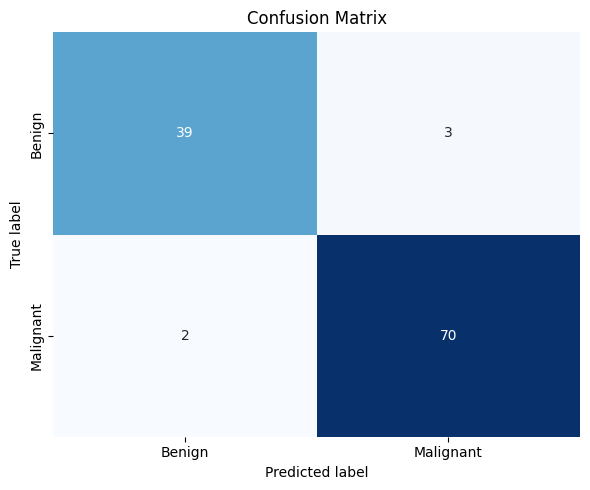

[AI DEBUG] Matriz de confusão salva em: presentation_workspace_demo/confusion_matrix.png
[AI DEBUG] Gerando curva ROC (se aplicável)


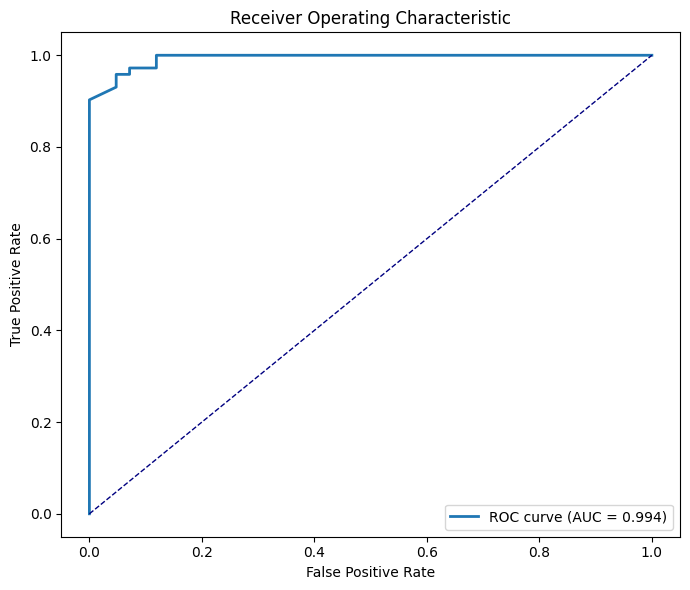

[AI DEBUG] Curva ROC salva em: presentation_workspace_demo/roc_curve.png
[AI DEBUG] Gerando gráfico de importâncias de atributo (se aplicável)


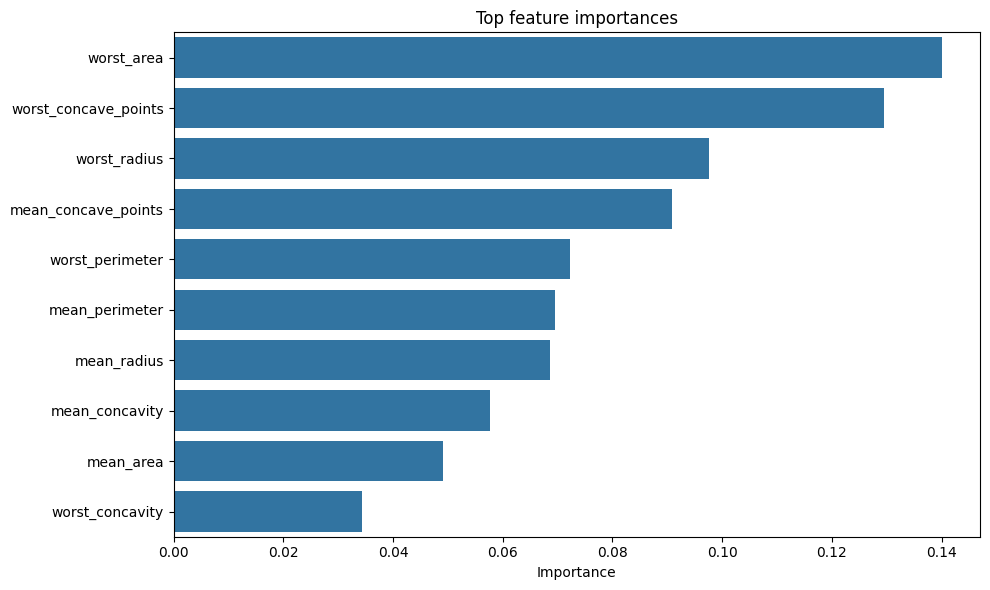

[AI DEBUG] Importâncias salvas em: presentation_workspace_demo/feature_importances.png
[AI DEBUG] Gerando justificativa de alinhamento com objetivo de negócio
[AI DEBUG] Justificativa salva em: presentation_workspace_demo/business_alignment.txt
[AI DEBUG] Salvando relatório consolidado em JSON
[AI DEBUG] Relatório JSON salvo em: presentation_workspace_demo/presentation_report.json
[AI DEBUG] Persistindo modelo final e artefatos
[AI DEBUG] Modelo salvo em: presentation_workspace_demo/final_model.joblib
Presentation artifacts created in presentation_workspace_demo/


In [13]:
# Presentation / Reporting module for Colab
# Block docstrings and @param annotations in English; debug prints in Portuguese.

"""
Presenter: document work, generate visuals, explain business alignment and produce a concise
report (markdown + saved figures). Designed to be atomic and composable.

@param modelObject: fitted model or pipeline used for final predictions (should implement predict and optionally predict_proba)
@param X_test: features for final evaluation (np.ndarray or pd.DataFrame)
@param y_test: labels for final evaluation (np.ndarray or pd.Series)
@param workspaceDirectoryPath: directory where report and figures will be saved
@param problemDescription: short string describing the business problem / objective
"""

from typing import Optional, Dict, Any, List, Union
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import textwrap
import joblib

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_fscore_support

class Presenter:
    """
    Presenter encapsulates creation of human-readable documentation and visualizations.

    @param modelObject: fitted model / pipeline (must implement predict; predict_proba optional)
    @param X_test: test features
    @param y_test: test labels
    @param workspaceDirectoryPath: base folder to write report and figures
    @param problemDescription: short description of business objective
    """

    def __init__(self,
                 modelObject: Any,
                 X_test: Union[np.ndarray, pd.DataFrame],
                 y_test: Union[np.ndarray, pd.Series],
                 workspaceDirectoryPath: str = "presentation_workspace",
                 problemDescription: str = "Binary classification to identify malignant vs benign tumors"):
        print("[AI DEBUG] Inicializando Presenter")
        self.modelObject = modelObject
        self.X_test = X_test
        self.y_test = np.asarray(y_test)
        self.workspaceDirectoryPath = Path(workspaceDirectoryPath)
        self.problemDescription = problemDescription

        # internal helpers
        self._make_dir = lambda p: Path(p).mkdir(parents=True, exist_ok=True)
        self._figure_path_for = lambda fig_id: self.workspaceDirectoryPath / f"{fig_id}.png"
        self._short = lambda s: (s if len(s) <= 160 else s[:157] + "...")
        self._ensure_workspace()

        # placeholders to be populated
        self.evaluationMetrics: Dict[str, Any] = {}
        self.classificationReportDict: Optional[Dict[str, Any]] = None
        self.generatedFigurePaths: List[str] = []

    def _ensure_workspace(self) -> None:
        """Ensure workspace exists"""
        print(f"[AI DEBUG] Criando/verificando workspace em: {self.workspaceDirectoryPath}")
        self._make_dir(self.workspaceDirectoryPath)

    def documentWhatWasDone(self,
                            chronologicalStepsList: Optional[List[str]] = None,
                            assumptionsList: Optional[List[str]] = None,
                            systemLimitationsList: Optional[List[str]] = None) -> str:
        """
        Produce a structured textual log of work performed.

        @param chronologicalStepsList: list of step descriptions in chronological order
        @param assumptionsList: list of declared assumptions
        @param systemLimitationsList: list of system limitations
        @return: markdown text of the documentation
        """
        print("[AI DEBUG] Documentando o que foi feito (gerando sumário em markdown)")
        chronologicalStepsList = chronologicalStepsList or [
            "Framed the problem and defined business objective",
            "Acquired WDBC dataset and validated integrity",
            "Performed exploratory data analysis (EDA) and derived insights",
            "Prepared data: imputation, scaling, PCA where applicable",
            "Trained multiple candidate models and shortlisted top models",
            "Fine-tuned hyperparameters via randomized search",
            "Built ensembles and evaluated final model on hold-out test set",
            "Persisted best model pipeline for deployment"
        ]
        assumptionsList = assumptionsList or [
            "Dataset observations are independent",
            "Labels provided are correct",
            "No PII present; data anonymized"
        ]
        systemLimitationsList = systemLimitationsList or [
            "Model trained on this dataset may not generalize to different imaging pipelines",
            "No external clinical data used (demographics/genomics available would improve performance)"
        ]
        markdown_lines = []
        markdown_lines.append(f"# Project Report: {self._short(self.problemDescription)}\n")
        markdown_lines.append("## 1. What was done\n")
        for i, step in enumerate(chronologicalStepsList, 1):
            markdown_lines.append(f"{i}. {step}\n")
        markdown_lines.append("\n## 2. Assumptions\n")
        for a in assumptionsList:
            markdown_lines.append(f"- {a}\n")
        markdown_lines.append("\n## 3. System limitations\n")
        for l in systemLimitationsList:
            markdown_lines.append(f"- {l}\n")
        markdown_content = "\n".join(markdown_lines)
        report_path = self.workspaceDirectoryPath / "project_summary.md"
        report_path.write_text(markdown_content, encoding="utf-8")
        print(f"[AI DEBUG] Documentação salva em markdown: {report_path}")
        return str(report_path)

    def evaluateFinalModel(self, positiveLabel: Optional[Union[int, str]] = 1) -> Dict[str, Any]:
        """
        Evaluate model on the test set and store evaluation metrics.

        @param positiveLabel: label value considered positive class (for labeling in confusion matrix)
        @return: dict with metrics and classification report
        """
        print("[AI DEBUG] Avaliando modelo final no conjunto de teste")
        preds = self.modelObject.predict(self.X_test)
        # classification report dict
        cr = classification_report(self.y_test, preds, output_dict=True, zero_division=0)
        cm = confusion_matrix(self.y_test, preds)
        precision, recall, f1, support = precision_recall_fscore_support(self.y_test, preds, average='binary', zero_division=0)
        # ROC/AUC if probabilities available
        proba = None
        roc_auc_value = None
        if hasattr(self.modelObject, "predict_proba"):
            try:
                proba = self.modelObject.predict_proba(self.X_test)[:, 1]
                fpr, tpr, thresholds = roc_curve(self.y_test, proba)
                roc_auc_value = auc(fpr, tpr)
            except Exception:
                proba = None
                roc_auc_value = None
        else:
            # try decision_function
            if hasattr(self.modelObject, "decision_function"):
                try:
                    dec = self.modelObject.decision_function(self.X_test)
                    fpr, tpr, thresholds = roc_curve(self.y_test, dec)
                    roc_auc_value = auc(fpr, tpr)
                except Exception:
                    roc_auc_value = None

        metrics_dict = {
            "confusion_matrix": cm,
            "classification_report": cr,
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "roc_auc": float(roc_auc_value) if roc_auc_value is not None else None,
            "predictions_sample": preds[:10].tolist()
        }
        self.evaluationMetrics = metrics_dict
        self.classificationReportDict = cr
        print("[AI DEBUG] Avaliação concluída e armazenada em Presenter.evaluationMetrics")
        return metrics_dict

    def presentConfusionMatrix(self,
                               figId: str = "confusion_matrix",
                               classLabels: Optional[List[str]] = None) -> Path:
        """
        Plot and save confusion matrix heatmap.

        @param figId: identifier used to name the saved figure file
        @param classLabels: optional list of label names (y axis / x axis)
        @return: Path to saved PNG figure
        """
        print("[AI DEBUG] Gerando matriz de confusão")
        cm = self.evaluationMetrics.get("confusion_matrix")
        if cm is None:
            raise ValueError("Confusion matrix not found. Run evaluateFinalModel() first.")
        classLabels = classLabels or ["Negative", "Positive"]
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=classLabels, yticklabels=classLabels)
        plt.ylabel("True label")
        plt.xlabel("Predicted label")
        plt.title("Confusion Matrix")
        fig_path = self._figure_path_for(figId)
        plt.tight_layout()
        plt.savefig(fig_path, dpi=300)
        plt.show()
        self.generatedFigurePaths.append(str(fig_path))
        print(f"[AI DEBUG] Matriz de confusão salva em: {fig_path}")
        return fig_path

    def presentRocCurve(self, figId: str = "roc_curve") -> Optional[Path]:
        """
        Plot ROC curve if probabilities or scores are available; save figure.

        @param figId: identifier for saved figure
        @return: Path to saved PNG figure or None if not available
        """
        print("[AI DEBUG] Gerando curva ROC (se aplicável)")
        proba = None
        if hasattr(self.modelObject, "predict_proba"):
            try:
                proba = self.modelObject.predict_proba(self.X_test)[:,1]
            except Exception:
                proba = None
        elif hasattr(self.modelObject, "decision_function"):
            try:
                proba = self.modelObject.decision_function(self.X_test)
            except Exception:
                proba = None

        if proba is None:
            print("[AI DEBUG] Probabilidades/scores não disponíveis; pulando ROC")
            return None

        fpr, tpr, thresholds = roc_curve(self.y_test, proba)
        roc_auc_value = auc(fpr, tpr)
        plt.figure(figsize=(7,6))
        plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc_value:.3f})")
        plt.plot([0,1],[0,1], color="navy", linestyle="--", lw=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characteristic")
        plt.legend(loc="lower right")
        fig_path = self._figure_path_for(figId)
        plt.tight_layout()
        plt.savefig(fig_path, dpi=300)
        plt.show()
        self.generatedFigurePaths.append(str(fig_path))
        print(f"[AI DEBUG] Curva ROC salva em: {fig_path}")
        return fig_path

    def presentFeatureImportances(self, featureNames: Optional[List[str]] = None, figId: str = "feature_importances", topK: int = 20) -> Optional[Path]:
        """
        Plot feature importances for tree-based models or coefficients for linear models.

        @param featureNames: optional list of feature names matching model input order
        @param figId: identifier for saved figure
        @param topK: number of top features to visualize
        @return: Path to saved PNG figure or None if unavailable
        """
        print("[AI DEBUG] Gerando gráfico de importâncias de atributo (se aplicável)")
        model = self.modelObject
        importances = None
        names = None

        # If pipeline, try to access estimator step
        if hasattr(model, "named_steps") and isinstance(model, Pipeline):
            try:
                estimator = model.named_steps.get("estimator") or model.steps[-1][1]
            except Exception:
                estimator = None
        else:
            estimator = model

        if estimator is None:
            print("[AI DEBUG] Estimador não identificado; pulando importâncias")
            return None

        if hasattr(estimator, "feature_importances_"):
            importances = estimator.feature_importances_
            names = featureNames or [f"feat_{i}" for i in range(len(importances))]
        elif hasattr(estimator, "coef_"):
            try:
                coeffs = estimator.coef_
                # handle multi-class flattening
                if coeffs.ndim > 1:
                    coeffs = np.mean(coeffs, axis=0)
                importances = np.abs(coeffs).ravel()
                names = featureNames or [f"feat_{i}" for i in range(len(importances))]
            except Exception:
                importances = None

        if importances is None:
            print("[AI DEBUG] Nenhuma medida de importância disponível para este modelo")
            return None

        indices = np.argsort(importances)[::-1][:topK]
        top_names = [names[i] for i in indices]
        top_importances = importances[indices]

        plt.figure(figsize=(10,6))
        sns.barplot(x=top_importances, y=top_names)
        plt.xlabel("Importance")
        plt.title("Top feature importances")
        fig_path = self._figure_path_for(figId)
        plt.tight_layout()
        plt.savefig(fig_path, dpi=300)
        plt.show()
        self.generatedFigurePaths.append(str(fig_path))
        print(f"[AI DEBUG] Importâncias salvas em: {fig_path}")
        return fig_path

    def explainWhySolutionMeetsBusinessObjective(self,
                                                businessMetric: str = "recall",
                                                thresholdForAcceptablePerformance: Optional[float] = None) -> str:
        """
        Generate a concise, evidence-based explanation linking metrics to business objective.

        @param businessMetric: primary business metric (e.g., 'recall' to minimize false negatives)
        @param thresholdForAcceptablePerformance: numeric threshold the business requires (optional)
        @return: textual explanation
        """
        print("[AI DEBUG] Gerando justificativa de alinhamento com objetivo de negócio")
        metric_value = self.evaluationMetrics.get(businessMetric) if self.evaluationMetrics else None
        lines = []
        lines.append(f"Business objective: {self._short(self.problemDescription)}")
        if metric_value is not None:
            lines.append(f"Observed {businessMetric}: {metric_value:.3f}")
            if thresholdForAcceptablePerformance is not None:
                lines.append(f"Required {businessMetric} >= {thresholdForAcceptablePerformance:.3f}")
                if metric_value >= thresholdForAcceptablePerformance:
                    lines.append("Conclusion: performance meets the business requirement.")
                else:
                    lines.append("Conclusion: performance does NOT meet the business requirement; further tuning or additional data required.")
        else:
            lines.append("No metric available to compare; run evaluateFinalModel() first.")
        explanation = "\n".join(lines)
        # save explanation as short text file
        expl_path = self.workspaceDirectoryPath / "business_alignment.txt"
        expl_path.write_text(explanation, encoding="utf-8")
        print(f"[AI DEBUG] Justificativa salva em: {expl_path}")
        return explanation

    def saveReportJson(self) -> Path:
        """
        Save consolidated report (metrics + generated figure list + short summary) as JSON.

        @return: Path to saved JSON file
        """
        print("[AI DEBUG] Salvando relatório consolidado em JSON")
        report_obj = {
            "problemDescription": self.problemDescription,
            "evaluationMetrics": self.evaluationMetrics,
            "classificationReport": self.classificationReportDict,
            "generatedFigures": self.generatedFigurePaths
        }
        out_path = self.workspaceDirectoryPath / "presentation_report.json"
        out_path.write_text(json.dumps(report_obj, default=lambda o: str(o), indent=2), encoding="utf-8")
        print(f"[AI DEBUG] Relatório JSON salvo em: {out_path}")
        return out_path

    def persistModelAndArtifacts(self, modelPath: str = "presentation_workspace/final_model.joblib") -> Path:
        """
        Persist final model and return path.

        @param modelPath: destination filepath
        @return: Path to saved model
        """
        print("[AI DEBUG] Persistindo modelo final e artefatos")
        out_path = Path(modelPath)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(self.modelObject, out_path)
        print(f"[AI DEBUG] Modelo salvo em: {out_path}")
        return out_path

# Example usage (after tuning / selection)
if __name__ == "__main__":
    # assume tuner exists and tunedModels['Ensemble'] or tuner.best model saved in tuner.tunedModels
    # quick demo using sklearn dataset and random forest as "best model"
    from sklearn.datasets import load_breast_cancer
    from sklearn.ensemble import RandomForestClassifier
    payload = load_breast_cancer()
    demo_df = pd.DataFrame(payload.data, columns=[c.replace(" ", "_") for c in payload.feature_names])
    demo_df["target"] = payload.target
    X = demo_df.drop(columns=["target"])
    y = demo_df["target"]
    from sklearn.model_selection import train_test_split
    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X.values, y.values, test_size=0.2, random_state=42, stratify=y)
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_d, y_train_d)

    presenter = Presenter(modelObject=rf, X_test=X_test_d, y_test=y_test_d, workspaceDirectoryPath="presentation_workspace_demo",
                          problemDescription="Breast cancer malignancy classification to minimize false negatives")
    presenter.documentWhatWasDone()
    presenter.evaluateFinalModel()
    presenter.presentConfusionMatrix(classLabels=["Benign","Malignant"])
    presenter.presentRocCurve()
    presenter.presentFeatureImportances(featureNames=list(demo_df.drop(columns=["target"]).columns), topK=10)
    explanation = presenter.explainWhySolutionMeetsBusinessObjective(businessMetric="recall", thresholdForAcceptablePerformance=0.90)
    presenter.saveReportJson()
    presenter.persistModelAndArtifacts("presentation_workspace_demo/final_model.joblib")
    print("Presentation artifacts created in presentation_workspace_demo/")


In [17]:
# Launch module — prepare model for production, monitoring, retraining hooks and testing scaffolding.
# English docstrings with @param and Portuguese debug prints.

"""
Launcher: prepares and helps deploy ML model pipelines to production, provides monitoring and retraining hooks.

Responsibilities:
- persist/load model artifacts and metadata (versions)
- generate unit-test skeleton for model inputs/outputs
- expose a minimal Flask prediction endpoint factory (optional, run explicitly)
- provide monitoring helpers: performance evaluation, data-drift (PSI) detection, input validation
- provide retrain() hook and instructions to schedule it (cron / Airflow)
- provide alert() placeholder to integrate with email/Slack/pager systems

@param modelArtifactPath: base path to store models and metadata
@param monitoringWorkspacePath: path to store monitoring snapshots and logs
@param allowedLatencySeconds: conservative suggestion for request latency alerting
"""

from typing import Optional, Dict, Any, List, Tuple
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import joblib
import os
import hashlib
import inspect
from io import BytesIO # Import BytesIO
import tempfile # Import tempfile

# lightweight HTTP server for serving predictions (call createPredictionApp and run it explicitly)
from flask import Flask, request, jsonify

# metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

class Launcher:
    def __init__(self,
                 modelArtifactPath: str = "production_models",
                 monitoringWorkspacePath: str = "monitoring_workspace",
                 allowedLatencySeconds: float = 1.0):
        """
        @param modelArtifactPath: directory to persist model artifacts and metadata
        @param monitoringWorkspacePath: directory to persist monitoring logs and snapshots
        @param allowedLatencySeconds: threshold for per-request latency alerting
        """
        print("[AI DEBUG] Inicializando Launcher")
        self.modelArtifactPath = Path(modelArtifactPath)
        self.monitoringWorkspacePath = Path(monitoringWorkspacePath)
        self.allowedLatencySeconds = allowedLatencySeconds
        self.modelRegistryPath = self.modelArtifactPath / "registry.json"
        self.modelArtifactPath.mkdir(parents=True, exist_ok=True)
        self.monitoringWorkspacePath.mkdir(parents=True, exist_ok=True)
        # tiny lambdas
        self._sha1_of = lambda b: hashlib.sha1(b).hexdigest()
        self._now_iso = lambda: time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
        # load or init registry
        if self.modelRegistryPath.exists():
            try:
                with open(self.modelRegistryPath, "r", encoding="utf-8") as f:
                    self.modelRegistry = json.load(f)
            except Exception:
                self.modelRegistry = {}
        else:
            self.modelRegistry = {}
        print(f"[AI DEBUG] Launcher ready. artifactPath: {self.modelArtifactPath}, monitoringPath: {self.monitoringWorkspacePath}")

    # -------------------------------
    # Model persistence and registry
    # -------------------------------
    def saveModelArtifact(self, fittedPipelineOrModel, modelName: str, metadata: Optional[Dict[str, Any]] = None) -> Path:
        """
        Persist a fitted model/pipeline and register it in lightweight registry.

        @param fittedPipelineOrModel: fitted sklearn Pipeline or estimator
        @param modelName: human-friendly name for this model version
        @param metadata: optional dict with fields such as datasetHash, trainDate, notes
        @return: Path to saved artifact
        """
        print(f"[AI DEBUG] Salvando artefato de modelo: {modelName}")
        # Save to a temporary file to get byte representation for hashing
        with tempfile.NamedTemporaryFile(delete=False) as tmp_file:
            temp_path = Path(tmp_file.name)
            joblib.dump(fittedPipelineOrModel, temp_path)

        try:
            with open(temp_path, "rb") as f:
                model_bytes = f.read()
        finally:
            os.remove(temp_path)

        artifact_path = self.modelArtifactPath / f"{modelName}_{self._now_iso()}_{self._sha1_of(model_bytes)[:8]}.joblib"
        joblib.dump(fittedPipelineOrModel, artifact_path)
        entry = {
            "name": modelName,
            "artifact": str(artifact_path),
            "fingerprint": self._sha1_of(model_bytes),
            "saved_at": self._now_iso(),
            "metadata": metadata or {}
        }
        # update registry (append)
        versions = self.modelRegistry.get(modelName, [])
        versions.append(entry)
        self.modelRegistry[modelName] = versions
        with open(self.modelRegistryPath, "w", encoding="utf-8") as f:
            json.dump(self.modelRegistry, f, indent=2)
        print(f"[AI DEBUG] Modelo salvo em: {artifact_path}. Registry atualizado.")
        return artifact_path

    def loadModelArtifact(self, modelName: str, versionIndex: int = -1):
        """
        Load a model artifact by name and version index (default last).

        @param modelName: model logical name
        @param versionIndex: index to select version (default -1 => latest)
        @return: loaded object
        """
        print(f"[AI DEBUG] Carregando artefato do modelo: {modelName}, versão index={versionIndex}")
        versions = self.modelRegistry.get(modelName)
        if not versions:
            raise FileNotFoundError(f"No model named '{modelName}' in registry.")
        selected = versions[versionIndex]
        path = Path(selected["artifact"])
        if not path.exists():
            raise FileNotFoundError(f"Artifact file missing: {path}")
        obj = joblib.load(path)
        print(f"[AI DEBUG] Modelo carregado a partir de: {path}")
        return obj

    # -------------------------------
    # Prediction endpoint factory
    # -------------------------------
    def createPredictionApp(self, modelObject, inputFeatureNames: Optional[List[str]] = None, appName: str = "prediction_service") -> Flask:
        """
        Create a minimal Flask app that serves predictions. Run app.run(host='0.0.0.0', port=...) explicitly.

        @param modelObject: fitted model/pipeline that implements predict (and optionally predict_proba)
        @param inputFeatureNames: optional list of expected JSON keys for input features (order matters if model expects array)
        @param appName: flask app name
        @return: Flask app instance (call run() externally)
        """
        print("[AI DEBUG] Criando Flask prediction app (execute app.run() explicitamente para expor serviço)")
        app = Flask(appName)
        model = modelObject
        feature_names = inputFeatureNames or []

        @app.route("/health", methods=["GET"])
        def health():
            return jsonify({"status": "ok", "time": self._now_iso()})

        @app.route("/predict", methods=["POST"])
        def predict():
            start = time.time()
            payload = request.get_json(force=True)
            # validate input
            if feature_names:
                missing = [f for f in feature_names if f not in payload]
                if missing:
                    return jsonify({"error": f"Missing features: {missing}"}), 400
                # prepare row in right order
                row = [payload[f] for f in feature_names]
                X = np.array(row).reshape(1, -1)
            else:
                # expect user to send {"instances": [[...], [...]] } or a single dict of feature_name->value
                if isinstance(payload, dict) and "instances" in payload:
                    X = np.asarray(payload["instances"])
                elif isinstance(payload, dict):
                    # convert single dict to single-row
                    X = np.asarray([list(payload.values())])
                else:
                    return jsonify({"error": "Unrecognized input format"}), 400
            try:
                preds = model.predict(X).tolist()
                probs = None
                if hasattr(model, "predict_proba"):
                    try:
                        probs = model.predict_proba(X).tolist()
                    except Exception:
                        probs = None
                latency = time.time() - start
                # latency alert check (log only here)
                if latency > self.allowedLatencySeconds:
                    print(f"[AI ALERT] Request latency high: {latency:.3f}s (threshold {self.allowedLatencySeconds}s)")
                response = {"predictions": preds, "probabilities": probs, "latency_seconds": latency}
                return jsonify(response)
            except Exception as e:
                return jsonify({"error": str(e)}), 500

        return app

    # -------------------------------
    # Unit test skeleton generator
    # -------------------------------
    def generateUnitTestSkeleton(self, modelObject, exampleInput: Dict[str, Any], testFilePath: str = "tests/test_model_inference.py") -> Path:
        """
        Create a pytest skeleton file that asserts model returns expected types and shapes.

        @param modelObject: fitted model/pipeline to document expected behavior
        @param exampleInput: example JSON-like input (dict) to pass to model/predict endpoint or pipeline
        @param testFilePath: path where to write the test skeleton
        @return: Path to the written test file
        """
        print("[AI DEBUG] Gerando skeleton de teste unitário (pytest)")
        test_path = Path(testFilePath)
        test_path.parent.mkdir(parents=True, exist_ok=True)
        content = f'''import json
import numpy as np
from joblib import load

def test_model_inference_shape_and_type():
    # Load model artifact manually (adjust the path if needed)
    model = load("{str(list(self.modelArtifactPath.glob('*.joblib'))[0])}")
    example = {json.dumps(exampleInput)}
    # Convert to numpy array similar to production preprocessor usage
    X = np.array(list(example.values())).reshape(1, -1)
    preds = model.predict(X)
    assert hasattr(preds, "__len__")
    assert len(preds) == 1
'''
        test_path.write_text(content, encoding="utf-8")
        print(f"[AI DEBUG] Test skeleton salvo em: {test_path}")
        return test_path

    # -------------------------------
    # Monitoring helpers
    # -------------------------------
    def computeBasicMetrics(self, y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
        """
        Compute a small set of classification metrics.

        @param y_true: true labels
        @param y_pred: predicted labels
        @return: dict with accuracy, precision, recall, f1, optional roc_auc if probs present externally
        """
        print("[AI DEBUG] Calculando métricas básicas de performance")
        metrics = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0))
        }
        print(f"[AI DEBUG] Metrics: {metrics}")
        return metrics

    def populationStabilityIndex(self, expected: np.ndarray, actual: np.ndarray, buckets: int = 10) -> float:
        """
        Compute PSI (Population Stability Index) between expected and actual numeric distributions.

        @param expected: reference 1D array (train/validation)
        @param actual: new 1D array (production)
        @param buckets: number of quantile buckets (default 10)
        @return: psi value (float)
        """
        print("[AI DEBUG] Calculando PSI (Population Stability Index)")
        # small helper lambdas
        _pct = lambda arr: arr / len(arr)
        try:
            quantiles = np.linspace(0, 1, buckets + 1)
            breaks = np.quantile(expected, quantiles)
            # ensure monotonic bins
            eps = 1e-8
            breaks = np.unique(np.clip(breaks, a_min=None, a_max=None))
            expected_counts, _ = np.histogram(expected, bins=breaks)
            actual_counts, _ = np.histogram(actual, bins=breaks)
            expected_pct = _pct(expected_counts + eps)
            actual_pct = _pct(actual_counts + eps)
            psi_val = np.sum((expected_pct - actual_pct) * np.log(expected_pct / actual_pct))
            print(f"[AI DEBUG] PSI computed: {psi_val:.6f}")
            return float(psi_val)
        except Exception as e:
            print(f"[AI DEBUG] PSI computation failed: {e}")
            return float("nan")

    def detectFeatureDrift(self, referenceDF: pd.DataFrame, productionDF: pd.DataFrame, numericThresholdPsi: float = 0.1) -> Dict[str, Any]:
        """
        For each numeric column compute PSI and report features that exceed threshold.

        @param referenceDF: historical reference dataset (DataFrame)
        @param productionDF: recent production inputs (DataFrame)
        @param numericThresholdPsi: threshold above which drift is flagged
        @return: dict mapping feature->psi for flagged features and full psi dict
        """
        print("[AI DEBUG] Detectando drift por feature via PSI")
        psi_by_feature = {}
        flagged = {}
        numeric_cols = referenceDF.select_dtypes(include=[np.number]).columns.intersection(productionDF.select_dtypes(include=[np.number]).columns)
        for col in numeric_cols:
            ref = referenceDF[col].dropna().values
            prod = productionDF[col].dropna().values
            if len(ref) < 50 or len(prod) < 50:
                psi_by_feature[col] = np.nan
                continue
            psi_val = self.populationStabilityIndex(ref, prod, buckets=10)
            psi_by_feature[col] = psi_val
            if not np.isnan(psi_val) and psi_val > numericThresholdPsi:
                flagged[col] = psi_val
        print(f"[AI DEBUG] Drift flagged features: {flagged}")
        return {"flagged": flagged, "psi_by_feature": psi_by_feature}

    def snapshotProductionInputs(self, productionInputsDF: pd.DataFrame, snapshotName: Optional[str] = None) -> Path:
        """
        Persist a snapshot of recent production inputs for offline inspection.

        @param productionInputsDF: DataFrame of recent inputs
        @param snapshotName: optional name; defaults to timestamp
        @return: path to saved CSV
        """
        snapshotName = snapshotName or f"inputs_snapshot_{self._now_iso()}"
        dest = self.monitoringWorkspacePath / f"{snapshotName}.csv"
        productionInputsDF.to_csv(dest, index=False)
        print(f"[AI DEBUG] Snapshot de inputs salvo em: {dest}")
        return dest

    # -------------------------------
    # Alerting placeholder
    # -------------------------------
    def alert(self, subject: str, body: str, channels: Optional[List[str]] = None) -> None:
        """
        Placeholder to send alerts. Integrate with your preferred system: Slack webhook, SMTP, PagerDuty, etc.

        @param subject: brief subject/title
        @param body: detailed body text
        @param channels: list of channel identifiers (optional)
        """
        print("[AI ALERT] Alert triggered:")
        print(f"   Subject: {subject}")
        print(f"   Body: {body}")
        print(f"   Channels: {channels or ['console only']}")
        # TODO: integrate with real alerting systems (requests.post to Slack webhook, smtplib for email, etc.)

    # -------------------------------
    # Retraining orchestration hook
    # -------------------------------
    def retrainHook(self,
                    trainingFunction,
                    trainingArgs: Optional[Dict[str, Any]] = None,
                    validationData: Optional[Tuple[np.ndarray, np.ndarray]] = None,
                    trackMetadata: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
        """
        Retrain model using provided trainingFunction. This is a synchronous, explicit call.
        You must supply a training function that returns the fitted pipeline/model and optionally metrics.

        @param trainingFunction: callable that performs training and returns (fittedModel, metadataDict)
        @param trainingArgs: optional dict of kwargs to pass to trainingFunction
        @param validationData: optional tuple (X_val, y_val) to compute validation metrics after training
        @param trackMetadata: optional dict to merge into persisted metadata
        @return: dict with 'artifact_path' and 'metrics' (if computed)
        """
        print("[AI DEBUG] Executando retrainHook (sincronamente) — forneça trainingFunction que treina e retorna fitted model")
        trainingArgs = trainingArgs or {}
        fitted_model, returned_metadata = trainingFunction(**trainingArgs)
        combined_metadata = {"trained_at": self._now_iso()}
        if returned_metadata:
            combined_metadata.update(returned_metadata)
        if trackMetadata:
            combined_metadata.update(trackMetadata)
        artifact_path = self.saveModelArtifact(fitted_model, modelName=combined_metadata.get("model_name", "model"), metadata=combined_metadata)
        metrics = None
        if validationData is not None:
            X_val, y_val = validation_data
            preds = fitted_model.predict(X_val)
            metrics = self.computeBasicMetrics(y_val, preds)
            print(f"[AI DEBUG] Validation metrics after retraining: {metrics}")
        return {"artifact_path": str(artifact_path), "metrics": metrics, "metadata": combined_metadata}

    # -------------------------------
    # Utilities
    # -------------------------------
    def recommendSchedulerIntegration(self) -> str:
        """
        Returns a short instruction snippet for scheduling monitoring and retraining.

        @return: string with recommended cron / Airflow / Kubernetes CronJob snippets
        """
        print("[AI DEBUG] Gerando recomendações para integração com scheduler (cron / Airflow)")
        cron_hint = text = (
            "Cron example (run every day at 02:00 UTC):\n"
            "0 2 * * * /usr/bin/python3 /opt/project/scripts/run_monitoring.py\n\n"
            "Airflow: create a DAG that calls monitoring and retrainHook tasks, set schedule_interval and retries.\n\n"
            "Kubernetes CronJob: use container image that mounts model artifact store and executes monitoring script.\n"
        )
        return cron_hint

# Example usage
if __name__ == "__main__":
    print("Demo: using Launcher with a dummy sklearn model (RandomForest trained on sklearn dataset)")
    from sklearn.datasets import load_breast_cancer
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    payload = load_breast_cancer()
    df = pd.DataFrame(payload.data, columns=[c.replace(" ", "_") for c in payload.feature_names])
    df["target"] = payload.target
    X = df.drop(columns=["target"]).values
    y = df["target"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)

    launcher = Launcher()
    # persist model
    artifact_path = launcher.saveModelArtifact(rf, modelName="rf_demo", metadata={"dataset": "sklearn_breast_cancer", "notes": "demo model"})
    # load and score
    model_loaded = launcher.loadModelArtifact("rf_demo")
    preds = model_loaded.predict(X_test)
    metrics = launcher.computeBasicMetrics(y_test, preds)
    # snapshot inputs (for monitoring)
    df_inputs = pd.DataFrame(X_test, columns=[c.replace(" ", "_") for c in payload.feature_names])
    launcher.snapshotProductionInputs(df_inputs, snapshotName="demo_test_inputs")
    # detect drift against train
    df_train = pd.DataFrame(X_train, columns=[c.replace(" ", "_") for c in payload.feature_names])
    drift_report = launcher.detectFeatureDrift(df_train, df_inputs)
    # generate flask app (run app.run externally to expose)
    app = launcher.createPredictionApp(model_loaded, inputFeatureNames=list(df_inputs.columns))
    print("Launcher demo complete. To run API server: call app.run(host='0.0.0.0', port=5000) explicitly.")

Demo: using Launcher with a dummy sklearn model (RandomForest trained on sklearn dataset)
[AI DEBUG] Inicializando Launcher
[AI DEBUG] Launcher ready. artifactPath: production_models, monitoringPath: monitoring_workspace
[AI DEBUG] Salvando artefato de modelo: rf_demo
[AI DEBUG] Modelo salvo em: production_models/rf_demo_2025-09-12T23:27:50Z_cc232a57.joblib. Registry atualizado.
[AI DEBUG] Carregando artefato do modelo: rf_demo, versão index=-1
[AI DEBUG] Modelo carregado a partir de: production_models/rf_demo_2025-09-12T23:27:50Z_cc232a57.joblib
[AI DEBUG] Calculando métricas básicas de performance
[AI DEBUG] Metrics: {'accuracy': 0.956140350877193, 'precision': 0.958904109589041, 'recall': 0.9722222222222222, 'f1': 0.9655172413793104}
[AI DEBUG] Snapshot de inputs salvo em: monitoring_workspace/demo_test_inputs.csv
[AI DEBUG] Detectando drift por feature via PSI
[AI DEBUG] Calculando PSI (Population Stability Index)
[AI DEBUG] PSI computation failed: One of max or min must be given
[

2025-09-12 23:28:10,680 | INFO | Pipeline start: orchestration iniciada
INFO:ml_pipeline:Pipeline start: orchestration iniciada
2025-09-12 23:28:10,682 | INFO | Framing: Breast Cancer Diagnostic Classification | Business objective: High recall to minimize false negatives
INFO:ml_pipeline:Framing: Breast Cancer Diagnostic Classification | Business objective: High recall to minimize false negatives
2025-09-12 23:28:10,684 | INFO | [ETAPA] Iniciando: DataManager.getData
INFO:ml_pipeline:[ETAPA] Iniciando: DataManager.getData


[AI DEBUG] Inicializando DataManager
1. List the data you need and how much you need.
   Need: Breast cancer diagnostic data with 30 numeric features computed from FNA images. Need at least several hundred samples for robust cross-validation.

2. Find and document where you can get that data.
   Preferred source: Kaggle dataset slug: yasserh/breast-cancer-dataset

3. Check how much space it will take.
   Expected size: very small (tens to hundreds of KB). Storage overhead negligible.

4. Check legal obligations, and get authorization if necessary.
   Dataset typically under CC BY 4.0 (UCI/Kaggle copies). Review license if redistributing or commercializing.

5. Get access authorizations.
   Access method: kagglehub (no kaggle.json needed). If using official Kaggle API, ensure kaggle.json present or env vars set.

6. Create a workspace (with enough storage space).
[AI DEBUG] Criando/verificando workspace e diretórios
[AI DEBUG] Diretório pronto: wdbc_workspace
[AI DEBUG] Diretório pronto

2025-09-12 23:28:12,231 | INFO | [ETAPA] Concluído: DataManager.getData
INFO:ml_pipeline:[ETAPA] Concluído: DataManager.getData
2025-09-12 23:28:12,241 | INFO | [ETAPA] Iniciando: ExploratoryAnalyzer.exploreData
INFO:ml_pipeline:[ETAPA] Iniciando: ExploratoryAnalyzer.exploreData


   Erro no download a partir do kagglehub ou carregamento do CSV: 'wdbc_workspace/raw' is not present in the dataset files. You can access the other files of the attached dataset at '/kaggle/input/breast-cancer-dataset'
   Carregando dataset de fallback do sklearn (load_breast_cancer)...
[AI DEBUG] Carregando dataset de fallback do sklearn.datasets.load_breast_cancer()
[AI DEBUG] Fallback dataset loaded. Shape: (569, 31)

8. Convert the data to a format you can easily manipulate (without changing the data itself).
   Using pandas DataFrame as canonical in-memory representation.

9. Ensure sensitive information is deleted or protected (e.g., anonymized).
[AI DEBUG] Nenhuma coluna a mascarar especificada; pulando anonimização

10. Check the size and type of data (time series, sample, geographical, etc.).
   Data type: Tabular. Samples: 569, Features (including target if present): 31

11. Sample a test set, put it aside, and never look at it (no data snooping!).
[AI DEBUG] Target detected

,name,dtype,missing_count,missing_pct,unique_count
0,mean_radius,float64,0,0.0,456
1,mean_texture,float64,0,0.0,479
2,mean_perimeter,float64,0,0.0,522
3,mean_area,float64,0,0.0,539
4,mean_smoothness,float64,0,0.0,474
5,mean_compactness,float64,0,0.0,537
6,mean_concavity,float64,0,0.0,537
7,mean_concave_points,float64,0,0.0,542
8,mean_symmetry,float64,0,0.0,432
9,mean_fractal_dimension,float64,0,0.0,499


   Estatísticas descritivas para atributos numéricos e categóricos
   No categorical columns to describe.


,count,mean,std,min,25%,50%,75%,max
mean_radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean_texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean_perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean_area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean_smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean_compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean_concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean_concave_points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean_symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean_fractal_dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


4. Identificando o(s) atributo(s) alvo para tarefas supervisionadas
   Target informado: target
   Target categórico detectado com distribuição: {1: 357, 0: 212}
   Visualizando distribuição do target


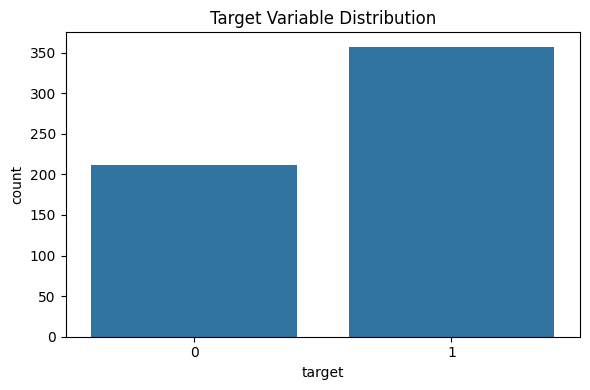

5. Visualizando atributos numéricos (histogramas + KDE)


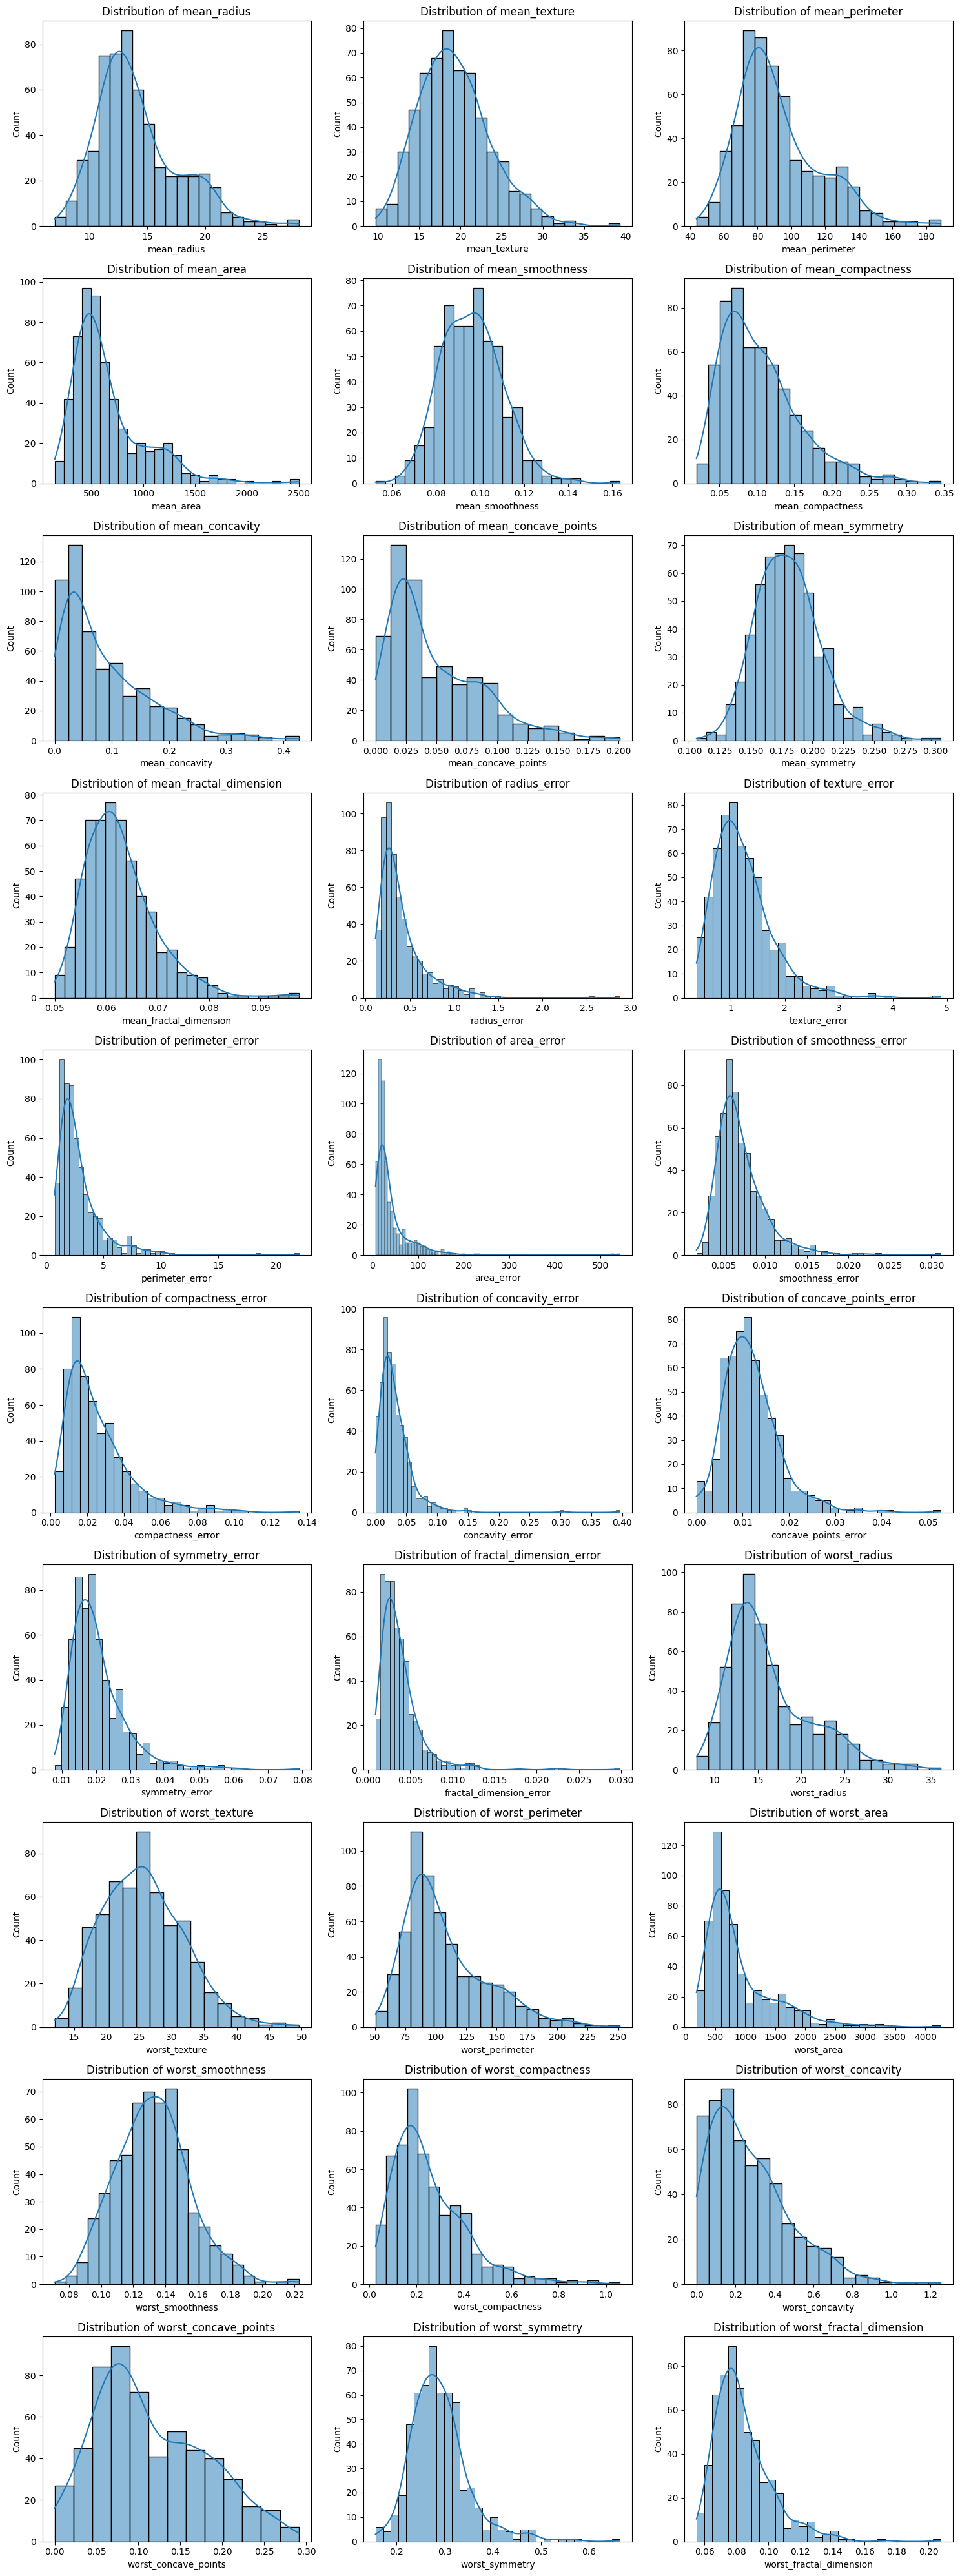

6. Estudando correlações entre atributos


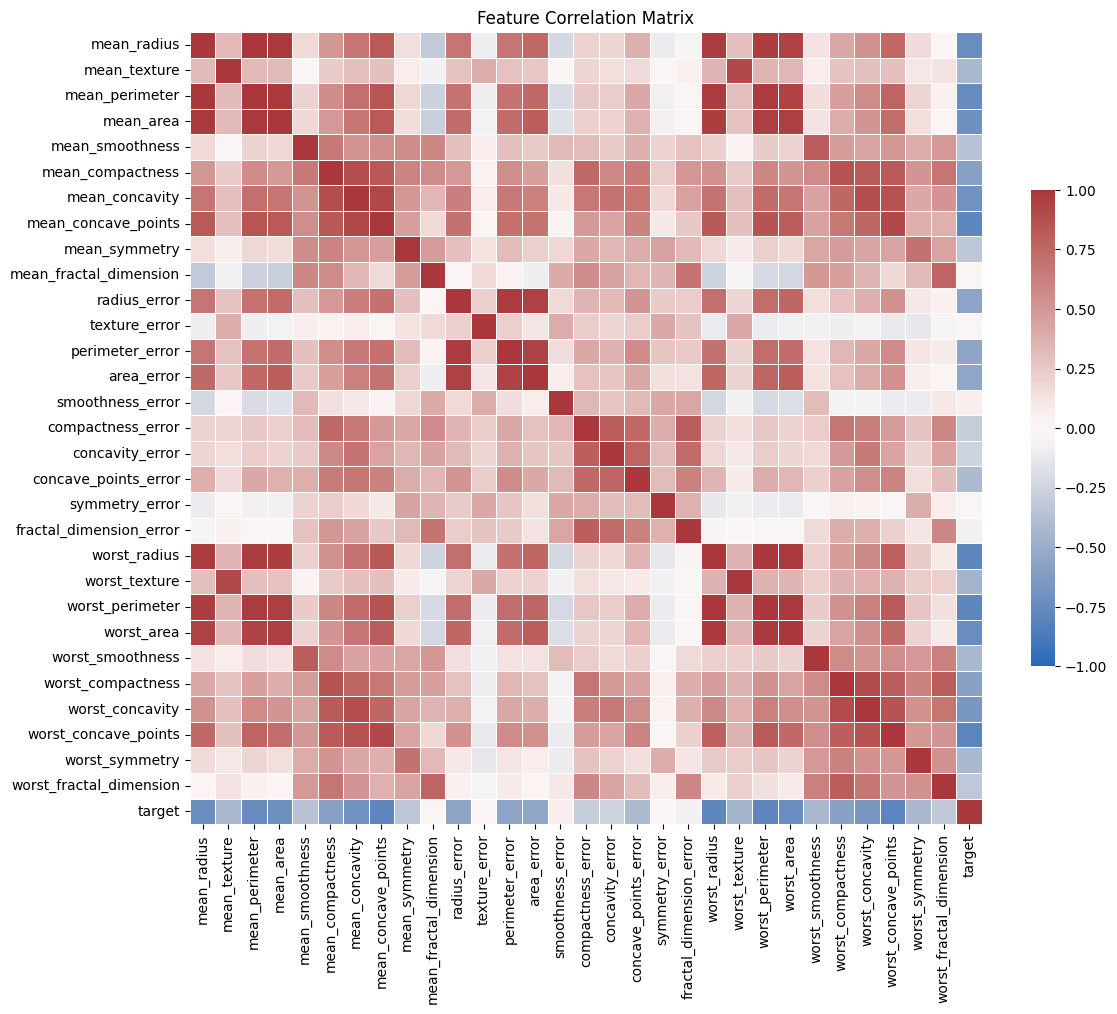

   Top features correlated with target (absolute correlation):


,abs_correlation
worst_concave_points,0.793566
worst_perimeter,0.782914
mean_concave_points,0.776614
worst_radius,0.776454
mean_perimeter,0.742636
worst_area,0.733825
mean_radius,0.730029
mean_area,0.708984
mean_concavity,0.696360
worst_concavity,0.659610


7. Estudando como resolver manualmente com expertise de domínio
   Manual solution sketch recorded
8. Identificando transformações promissoras
   Transformations suggested
9. Identificando dados extras úteis
   Suggested additional data: ['patient_demographics', 'family_history', 'genetic_markers', 'multi-modal imaging metadata']
10. Documentando o que foi aprendido durante a EDA


,value
targetColumn,target
targetIsCategorical,True
targetDistributionSample,"{1: 357, 0: 212}"
topCorrelatedWithTarget,"{'worst_concave_points': 0.79356601714127, 'wo..."
manualSolutionSketch,"Expert inspection of nucleus radius, texture, ..."
transformations,{'standardization': 'StandardScaler for numeri...
additionalDataSuggestions,"[patient_demographics, family_history, genetic..."
notes,EDA completed; consult findings keys for details


2025-09-12 23:28:22,954 | INFO | [ETAPA] Concluído: ExploratoryAnalyzer.exploreData
INFO:ml_pipeline:[ETAPA] Concluído: ExploratoryAnalyzer.exploreData
2025-09-12 23:28:22,955 | INFO | [ETAPA] Iniciando: DataPreparer.createWorkingCopyAndSplitIfNeeded
INFO:ml_pipeline:[ETAPA] Iniciando: DataPreparer.createWorkingCopyAndSplitIfNeeded
2025-09-12 23:28:22,957 | INFO | [ETAPA] Concluído: DataPreparer.createWorkingCopyAndSplitIfNeeded
INFO:ml_pipeline:[ETAPA] Concluído: DataPreparer.createWorkingCopyAndSplitIfNeeded
2025-09-12 23:28:22,959 | INFO | [ETAPA] Iniciando: DataPreparer.detectAndOptionallyRemoveOutliers
INFO:ml_pipeline:[ETAPA] Iniciando: DataPreparer.detectAndOptionallyRemoveOutliers
2025-09-12 23:28:22,972 | INFO | [ETAPA] Concluído: DataPreparer.detectAndOptionallyRemoveOutliers
INFO:ml_pipeline:[ETAPA] Concluído: DataPreparer.detectAndOptionallyRemoveOutliers
2025-09-12 23:28:22,974 | INFO | [ETAPA] Iniciando: DataPreparer.buildPreprocessingPipeline
INFO:ml_pipeline:[ETAPA] Ini

[AI DEBUG] EDA pipeline complete
[AI DEBUG] Initializing DataPreparer
[AI DEBUG] Pre-split data provided; loading splits
[AI DEBUG] DataPreparer initialized
1) Creating working copy and split if necessary
   Pre-split already available; skipping split.
2) Detecting and optionally removing outliers
   Using IQR rule for outlier detection
   IQR rule would remove 141 rows from training set
   Outliers removed via IQR rule.
4) Building preprocessing pipeline (scaling, optional PCA, atomic steps)
3) Building feature engineering transformer (atomic functions)
   Adding engineered feature: mean_area_to_mean_perimeter_ratio
   Adding engineered feature: mean_radius_to_mean_perimeter_ratio
   No categorical columns detected
   Feature engineering transformer built (base).
   Adding PCA to preserve 95% variance
   Preprocessing pipeline constructed and stored in self.pipeline_
5) Fitting preprocessing pipeline on training data and transforming train/test
   X_train_prepared shape: (314, 10)
   

,Model,CV_Mean,CV_Std,Test_Accuracy,Test_F1,Test_ROC_AUC
0,MLP,0.9777,0.0128,0.9649,0.9718,0.9937
1,SVC,0.9649,0.0212,0.8947,0.9200,0.9845
2,LogisticRegression,0.9649,0.0188,0.9737,0.9790,0.9977
3,RandomForest,0.9554,0.0273,0.8947,0.9143,0.9722
4,GradientBoosting,0.9522,0.0224,0.9211,0.9379,0.9769
5,KNN,0.9522,0.0224,0.9561,0.9655,0.9881
6,GaussianNB,0.9522,0.0144,0.9298,0.9444,0.9881
7,DecisionTree,0.9362,0.0304,0.8596,0.8841,0.8641


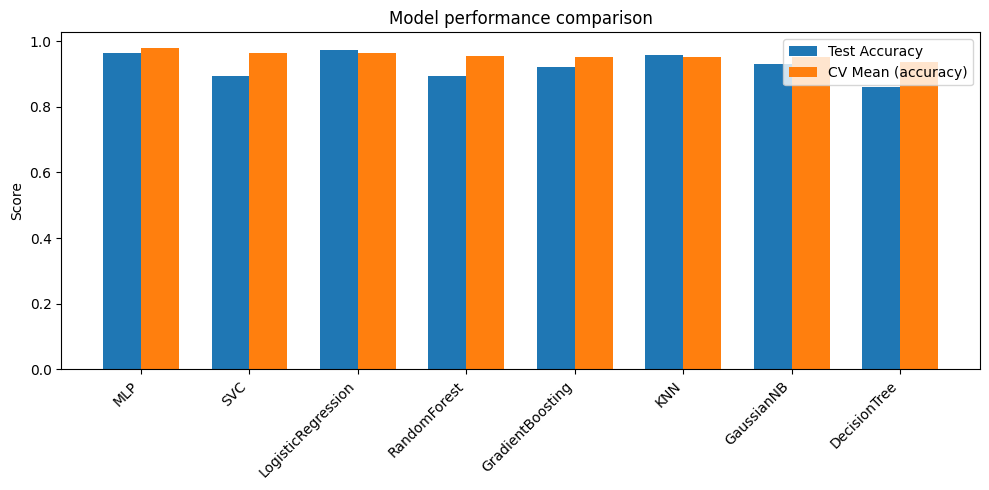

2025-09-12 23:28:28,791 | INFO | [ETAPA] Concluído: ModelShortlister.trainAndShortlist
INFO:ml_pipeline:[ETAPA] Concluído: ModelShortlister.trainAndShortlist
2025-09-12 23:28:28,794 | INFO | [ETAPA] Iniciando: FineTuner.tuneAllModels
INFO:ml_pipeline:[ETAPA] Iniciando: FineTuner.tuneAllModels



3. Modelos mais promissores selecionados:
   Top 3: ['MLP', 'SVC', 'LogisticRegression']
[AI DEBUG] Inicializando FineTuner
[AI DEBUG] FineTuner ready
[AI DEBUG] Iniciando tuning de todos os modelos candidatos
[AI DEBUG] Building default hyperparameter distributions (will be filtered against actual pipeline params)
[AI DEBUG] Default hyperparameter distributions assembled

[AI DEBUG] Tunando modelo: MLP


2025-09-12 23:28:33,385 | ERROR | [ERRO] Falha em FineTuner.tuneAllModels: Specifying the columns using strings is only supported for dataframes.
Traceback (most recent call last):
  File "/tmp/ipython-input-3787347834.py", line 256, in tuneAllModels
    self.tuneModel(modelName, estimator, param_distributions=space, nIter=nIter, cvFolds=cvFolds, scoring=scoring, useHalving=useHalving)
  File "/tmp/ipython-input-3787347834.py", line 222, in tuneModel
    searcher.fit(self.X_train, self.y_train)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py", line 1024, in fit
    self._run_search(evaluate_candidates)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py", line 1951, in _run_search
    evaluate_candidates(
  File "/usr/local/lib/python3.

[AI DEBUG] Falha no tuning do modelo MLP: 
All the 60 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_indexing.py", line 341, in _get_column_indices
    all_columns = X.columns
                  ^^^^^^^^^
AttributeError: 'numpy.ndarray' object has no attribute 'columns'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(est

In [18]:
# main_pipeline.py
# Orchestrator that calls the 8 pipeline classes in sequence.
# Assumes DataManager, ExploratoryAnalyzer, DataPreparer, ModelShortlister,
# FineTuner, Presenter, Launcher are already defined in the notebook scope.
# Logs in Portuguese, atomic steps, safe execution using safe_call.

import logging
import numpy as np
import random
import os
from typing import Any, Callable

GLOBAL_RANDOM_SEED = 42
np.random.seed(GLOBAL_RANDOM_SEED)
random.seed(GLOBAL_RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(GLOBAL_RANDOM_SEED)

logger = logging.getLogger("ml_pipeline")
logger.setLevel(logging.INFO)
if not logger.handlers:
    ch = logging.StreamHandler()
    ch.setLevel(logging.INFO)
    ch.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
    logger.addHandler(ch)

def safe_call(func: Callable, *args, step_name: str = "", **kwargs) -> Any:
    """Execute func catching exceptions; returns func result or None."""
    try:
        logger.info(f"[ETAPA] Iniciando: {step_name or func.__name__}")
        result = func(*args, **kwargs)
        logger.info(f"[ETAPA] Concluído: {step_name or func.__name__}")
        return result
    except Exception as exc:
        logger.exception(f"[ERRO] Falha em {step_name or func.__name__}: {exc}")
        return None

def main_pipeline():
    logger.info("Pipeline start: orchestration iniciada")

    # 1 Frame the problem (lightweight)
    frame_title = "Breast Cancer Diagnostic Classification"
    business_objective = "High recall to minimize false negatives"
    logger.info(f"Framing: {frame_title} | Business objective: {business_objective}")

    # 2 Data acquisition
    data_manager = DataManager(workspaceDirectoryPath="wdbc_workspace",
                               preferredKaggleDatasetSlug="yasserh/breast-cancer-dataset")
    safe_call(data_manager.getData, step_name="DataManager.getData")
    if getattr(data_manager, "dataFrame", None) is None:
        logger.error("Dados não disponíveis. Abortando pipeline.")
        return

    # 3 Exploratory Data Analysis
    analyzer = ExploratoryAnalyzer(dataset_dataframe=data_manager.dataFrame,
                                   target_column_name=data_manager.targetVariable,
                                   sample_max_rows=1000,
                                   random_state=GLOBAL_RANDOM_SEED)
    safe_call(analyzer.exploreData, step_name="ExploratoryAnalyzer.exploreData")

    # 4 Prepare the data (split / cleaning / pipeline)
    # prefer preSplit if DataManager created train/test
    pre_split = None
    if all(hasattr(data_manager, attr) for attr in ("X_train", "X_test", "y_train", "y_test")):
        pre_split = {"X_train": data_manager.X_train, "X_test": data_manager.X_test,
                     "y_train": data_manager.y_train, "y_test": data_manager.y_test}

    preparer = DataPreparer(inputDataFrame=data_manager.dataFrame,
                            inputTargetColumnName=data_manager.targetVariable,
                            preSplit=pre_split,
                            randomState=GLOBAL_RANDOM_SEED)

    safe_call(preparer.createWorkingCopyAndSplitIfNeeded, 0.2, True, step_name="DataPreparer.createWorkingCopyAndSplitIfNeeded")
    safe_call(preparer.detectAndOptionallyRemoveOutliers, method="iqr", iqrMultiplier=1.5, useIsolationForest=False,
              step_name="DataPreparer.detectAndOptionallyRemoveOutliers")
    safe_call(preparer.buildPreprocessingPipeline, usePCA=True, pcaVarianceThreshold=0.95,
              addFeatureEngineeringChoices=None, step_name="DataPreparer.buildPreprocessingPipeline")
    X_train_prepared, X_test_prepared = safe_call(preparer.fitTransformTrainAndTransformTest,
                                                  step_name="DataPreparer.fitTransformTrainAndTransformTest") or (None, None)
    if X_train_prepared is None:
        logger.error("Preparação falhou. Abortando pipeline.")
        return

    y_train = np.asarray(getattr(preparer, "y_train_raw", getattr(data_manager, "y_train", None)))
    y_test = np.asarray(getattr(preparer, "y_test_raw", getattr(data_manager, "y_test", None)))

    # 5 Shortlist promising models
    shortlister = ModelShortlister(X_train=X_train_prepared, X_test=X_test_prepared,
                                   y_train=y_train, y_test=y_test, nFolds=5, randomState=GLOBAL_RANDOM_SEED)
    safe_call(shortlister.trainAndShortlist, "accuracy", 3, step_name="ModelShortlister.trainAndShortlist")

    # 6 Fine-tune selected models
    # Build candidate_models from shortlister top results when available
    candidate_models = {}
    try:
        if shortlister.results_df is not None and not shortlister.results_df.empty:
            top_names = shortlister.results_df.head(3)["Model"].tolist()
            for n in top_names:
                if n in shortlister.models_catalog:
                    candidate_models[n] = shortlister.models_catalog[n]
    except Exception:
        candidate_models = {}
    if not candidate_models:
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.linear_model import LogisticRegression
        candidate_models = {"RandomForest": RandomForestClassifier(random_state=GLOBAL_RANDOM_SEED),
                            "LogisticRegression": LogisticRegression(max_iter=1000)}

    # ensure X_train/X_test formats match expected input type for FineTuner
    X_train_for_tuner = X_train_prepared
    X_test_for_tuner = X_test_prepared
    tuner = FineTuner(preprocessingPipeline=preparer.pipeline_,
                      candidateModelsDict=candidate_models,
                      X_train=X_train_for_tuner,
                      X_test=X_test_for_tuner,
                      y_train=y_train,
                      y_test=y_test,
                      randomState=GLOBAL_RANDOM_SEED,
                      nJobs=2)

    safe_call(tuner.tuneAllModels, None, nIter=20, cvFolds=3, scoring="accuracy", useHalving=False,
              step_name="FineTuner.tuneAllModels")
    # try ensemble if multiple tuned models
    if len(tuner.tunedModels) >= 2:
        safe_call(tuner.buildEnsemble, ensembleType="voting", voting="soft", stack_final_estimator=None,
                  step_name="FineTuner.buildEnsemble")
    safe_call(tuner.evaluateModels, step_name="FineTuner.evaluateModels")

    # 7 Present the solution
    # choose best model
    best_model_obj = None
    if tuner.finalResults is not None and not tuner.finalResults.empty:
        best_name = tuner.finalResults.iloc[0]["Model"]
        best_model_obj = tuner.tunedModels.get(best_name)
    elif "Ensemble" in tuner.tunedModels:
        best_model_obj = tuner.tunedModels["Ensemble"]
    else:
        best_model_obj = next(iter(tuner.tunedModels.values()), None)

    if best_model_obj is None:
        logger.error("Nenhum modelo final selecionado; pule apresentação e lançamento.")
    else:
        presenter = Presenter(modelObject=best_model_obj,
                              X_test=X_test_for_tuner,
                              y_test=y_test,
                              workspaceDirectoryPath="presentation_workspace",
                              problemDescription=business_objective)
        safe_call(presenter.documentWhatWasDone, step_name="Presenter.documentWhatWasDone")
        safe_call(presenter.evaluateFinalModel, step_name="Presenter.evaluateFinalModel")
        safe_call(presenter.presentConfusionMatrix, classLabels=["Benign", "Malignant"], step_name="Presenter.presentConfusionMatrix")
        safe_call(presenter.presentRocCurve, step_name="Presenter.presentRocCurve")
        safe_call(presenter.presentFeatureImportances, featureNames=preparer.featureNamesAfterProcessing, topK=10,
                  step_name="Presenter.presentFeatureImportances")
        safe_call(presenter.saveReportJson, step_name="Presenter.saveReportJson")

    # 8 Launch: persist, unit-test skeleton, monitoring snapshot and drift check
    launcher = Launcher(modelArtifactPath="production_models", monitoringWorkspacePath="monitoring_workspace", allowedLatencySeconds=1.0)
    if best_model_obj is not None:
        artifact_path = safe_call(launcher.saveModelArtifact, best_model_obj, "final_model", {"seed": GLOBAL_RANDOM_SEED},
                                  step_name="Launcher.saveModelArtifact")
        # create example input for unit test skeleton
        example_input = {}
        try:
            if hasattr(preparer, "X_test_raw") and preparer.X_test_raw is not None:
                if hasattr(preparer.X_test_raw, "columns"):
                    example_input = preparer.X_test_raw.iloc[0].to_dict()
                else:
                    first_row = preparer.X_test_raw[0]
                    example_input = {f"feat_{i}": float(v) for i, v in enumerate(first_row)}
        except Exception:
            example_input = {}
        safe_call(launcher.generateUnitTestSkeleton, best_model_obj, example_input, "tests/test_model_inference.py",
                  step_name="Launcher.generateUnitTestSkeleton")

    # monitoring example
    try:
        if hasattr(preparer, "X_train_raw") and hasattr(preparer, "X_test_raw") and preparer.X_train_raw is not None and preparer.X_test_raw is not None:
            ref_df = preparer.X_train_raw if hasattr(preparer.X_train_raw, "columns") else None
            prod_df = preparer.X_test_raw if hasattr(preparer.X_test_raw, "columns") else None
            if ref_df is not None and prod_df is not None:
                safe_call(launcher.snapshotProductionInputs, prod_df, "post_deploy_snapshot", step_name="Launcher.snapshotProductionInputs")
                drift_report = safe_call(launcher.detectFeatureDrift, ref_df, prod_df, numericThresholdPsi=0.1, step_name="Launcher.detectFeatureDrift")
                logger.info("Drift flagged: %s", drift_report.get("flagged") if drift_report else {})
    except Exception as exc:
        logger.exception("Erro durante monitoramento: %s", exc)

    logger.info("Pipeline finished. Check folders: wdbc_workspace, presentation_workspace, production_models, monitoring_workspace")

if __name__ == "__main__":
    main_pipeline()
